### Load in Protein Data

In [50]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

# Load files on Evan's Laptop
# expr_orig = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\expression.csv", index_col=0)
# expr=expr_orig.transpose()
# metadata = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\metadata.csv", index_col=0)
# umap = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\umap.csv", index_col=0)

#Load files on Lab computer
expr_orig = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\expression.csv", index_col=0)
expr=expr_orig.transpose()
metadata = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\metadata.csv", index_col=0)
umap = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\umap.csv", index_col=0)

# Create AnnData object
adata = sc.AnnData(X=expr.values)

# Assign metadata
adata.obs = metadata
adata.var_names = expr.columns
adata.obs_names = expr.index

# Add spatial coordinates and UMAP to .obsm
# adata.obsm["spatial"] = metadata[['x_FOV_px', 'y_FOV_px']].values  # adjust if needed
adata.obsm["spatial"] = metadata[['x_FOV_px']].assign(y_FOV_px = -metadata['y_FOV_px']).values
adata.obsm["X_umap"] = umap.values

### Analysis of co-localization spatial matrix

On some of the samples I noticed that some of the PMN cells have low colocalization with other immmune cells despite being close (but maybe not touching) geographically. 

This contains analysis of PMN cell interaction. Namly
* How many cells are considering interacting with PMNs on average
* What types of cells do PMNs iteract with
* The potential of changing to a radial plot

Notes: 
* Interestinly the delaunay method only seems to show the 6 nearest cells. Allways just slightly below that number. 

# Neighbooring Cell Percentages 

Function which loops the the cell types neighbooring each PMN. Spits out a results like (60% fibroblast 15% CD8 cells 15% Tumor 10% Other)

#### Neighbooring Cell Percentages - Individual Sample (Pie + Percentage) 

[NbConvertApp] Converting notebook my_functions.ipynb to python
[NbConvertApp] Writing 24127 bytes to my_functions.py


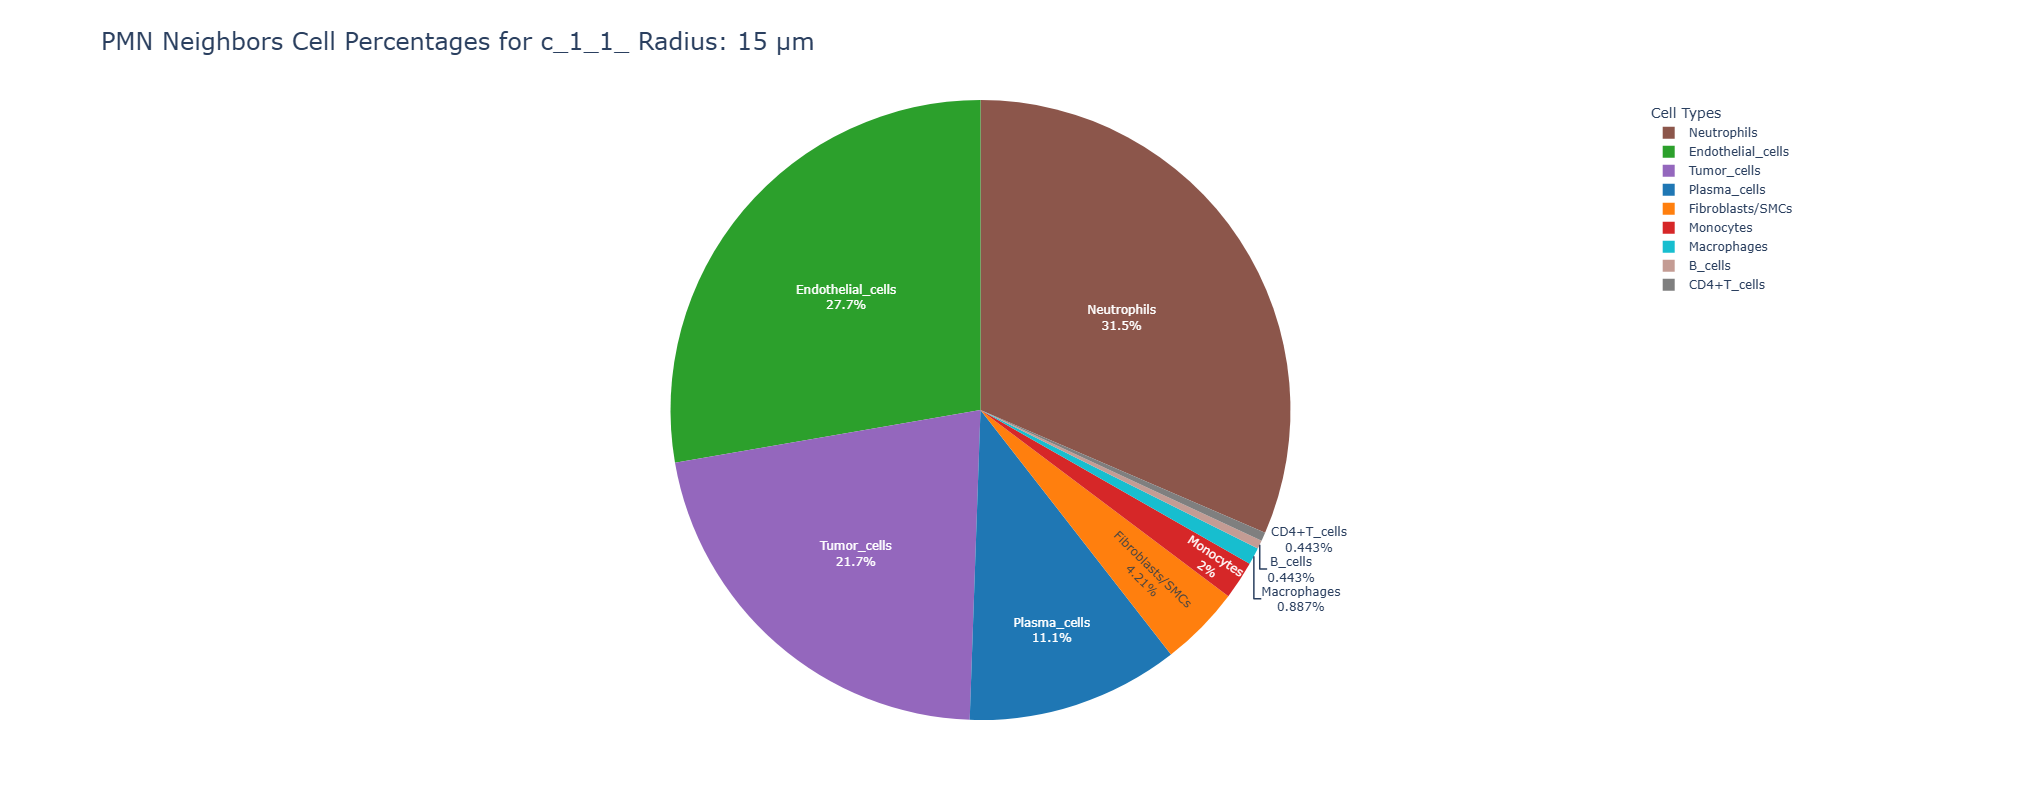

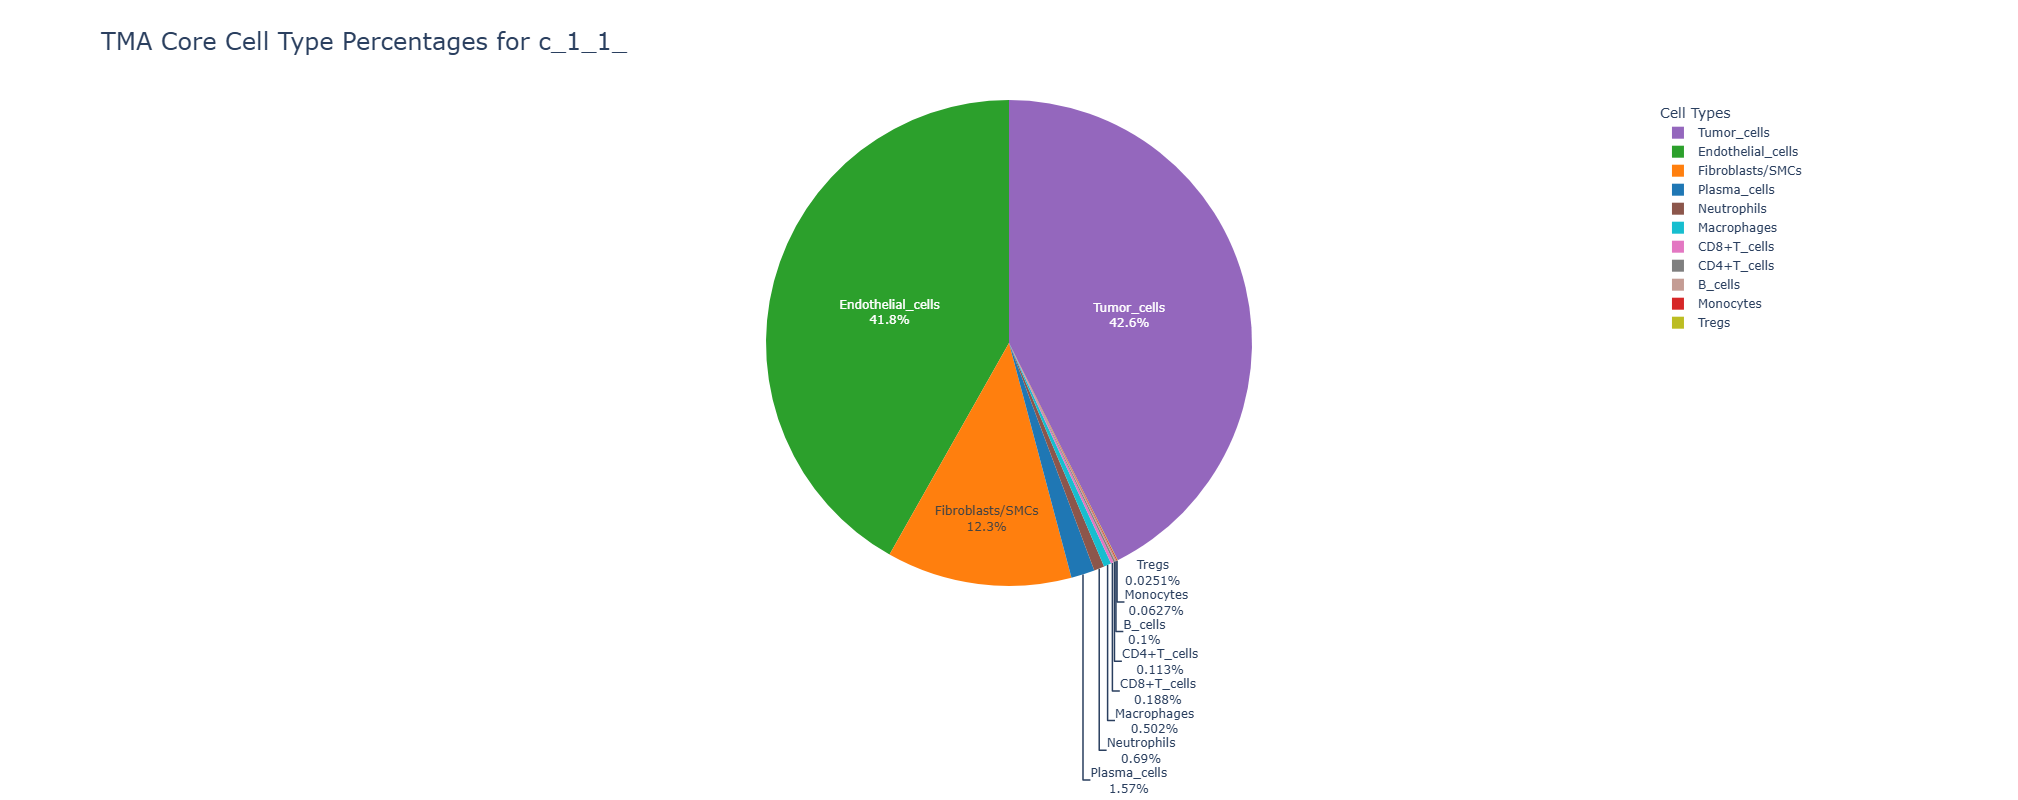

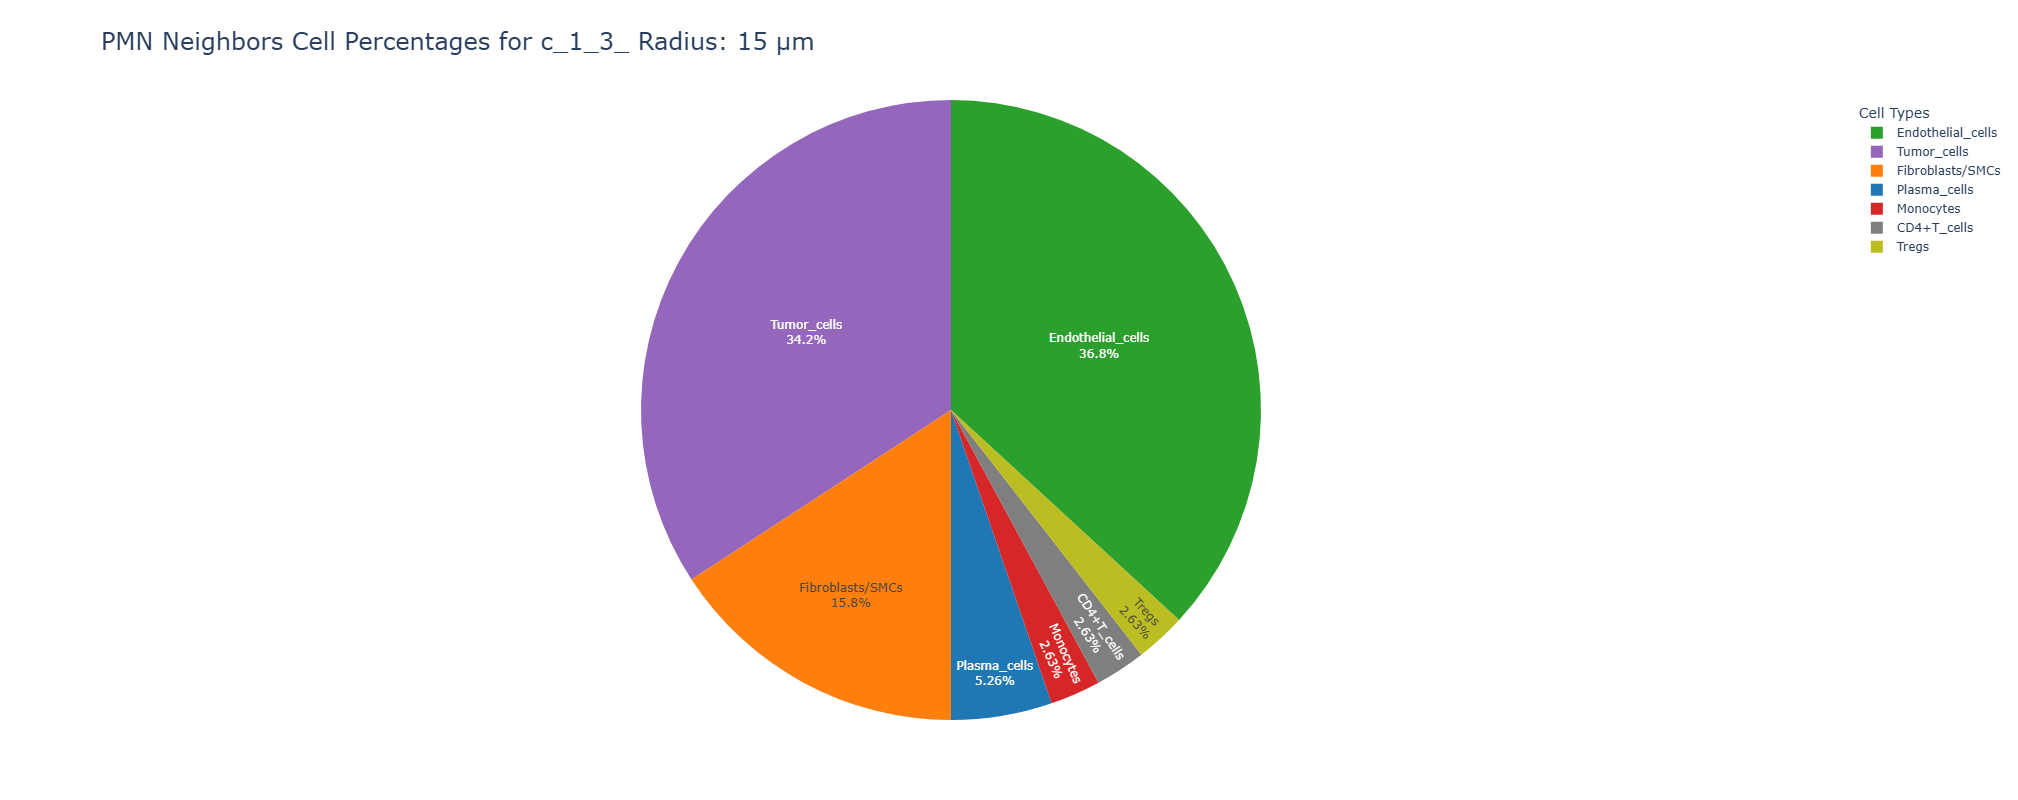

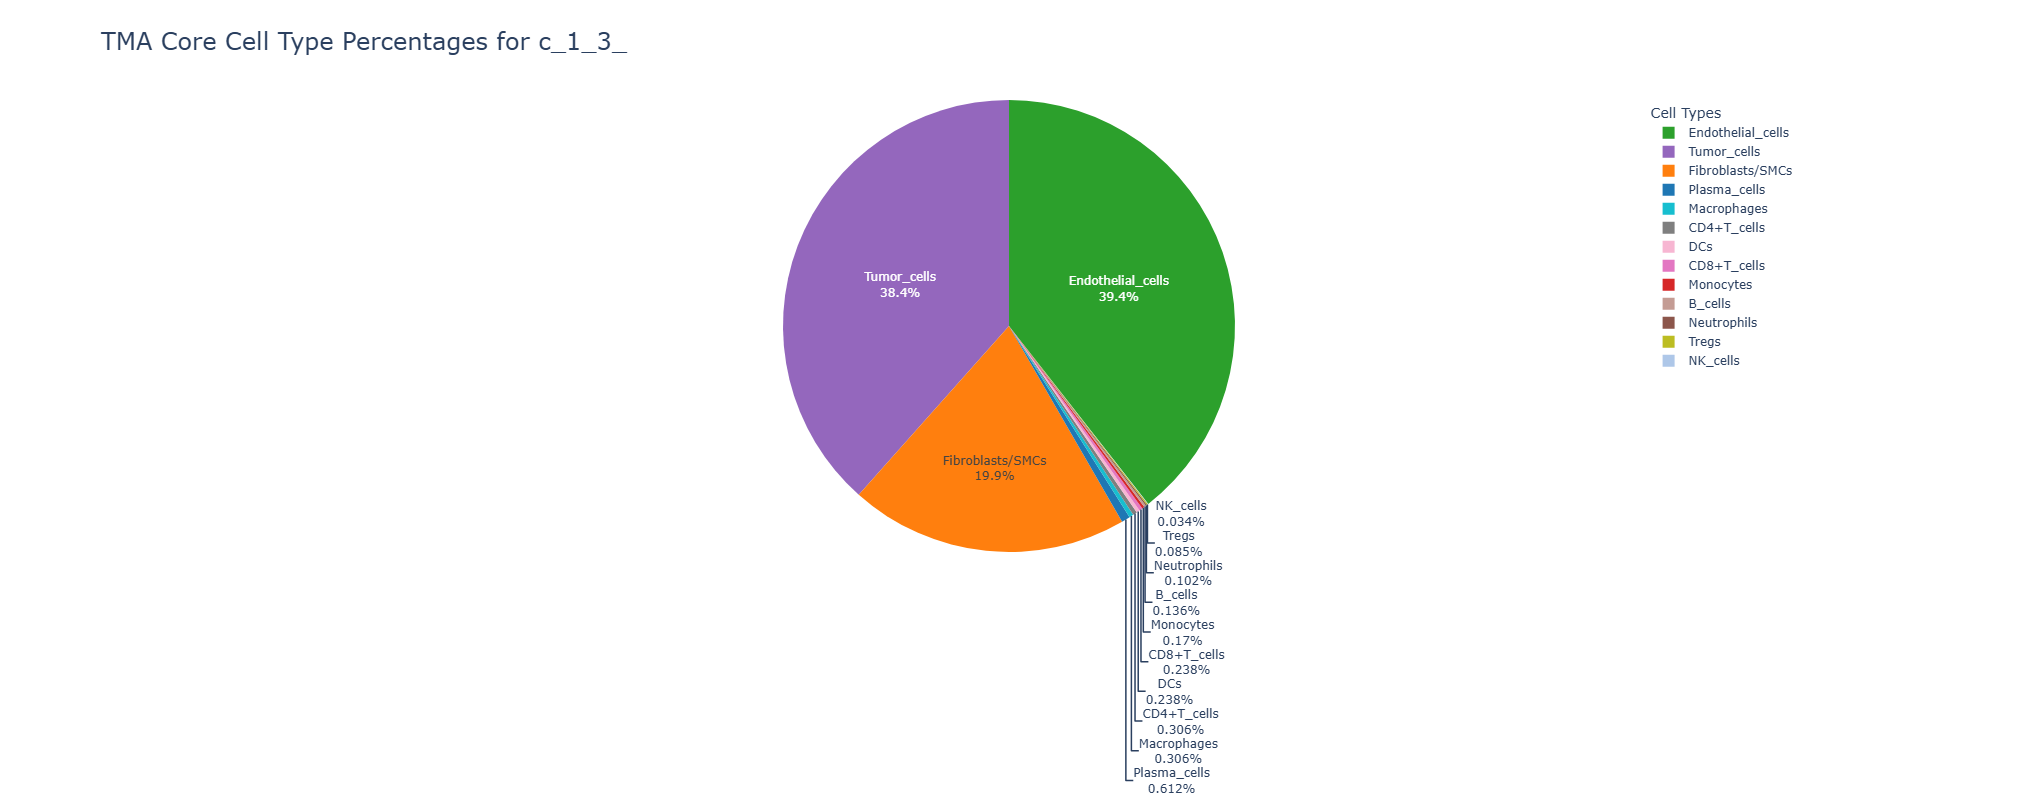

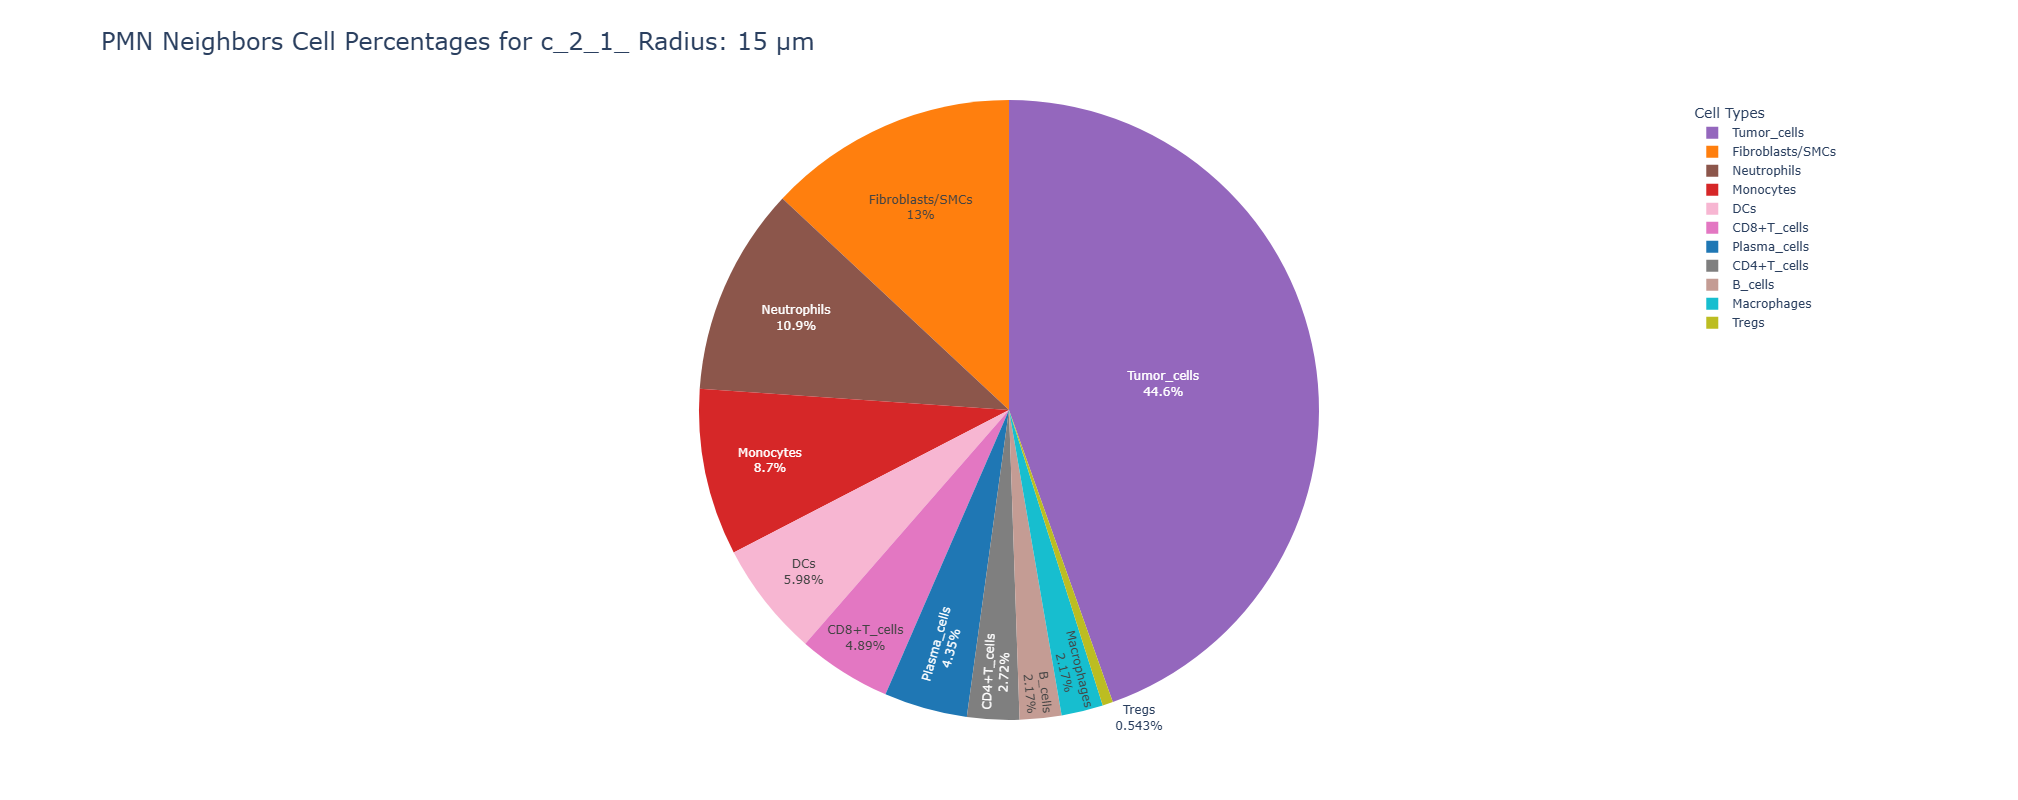

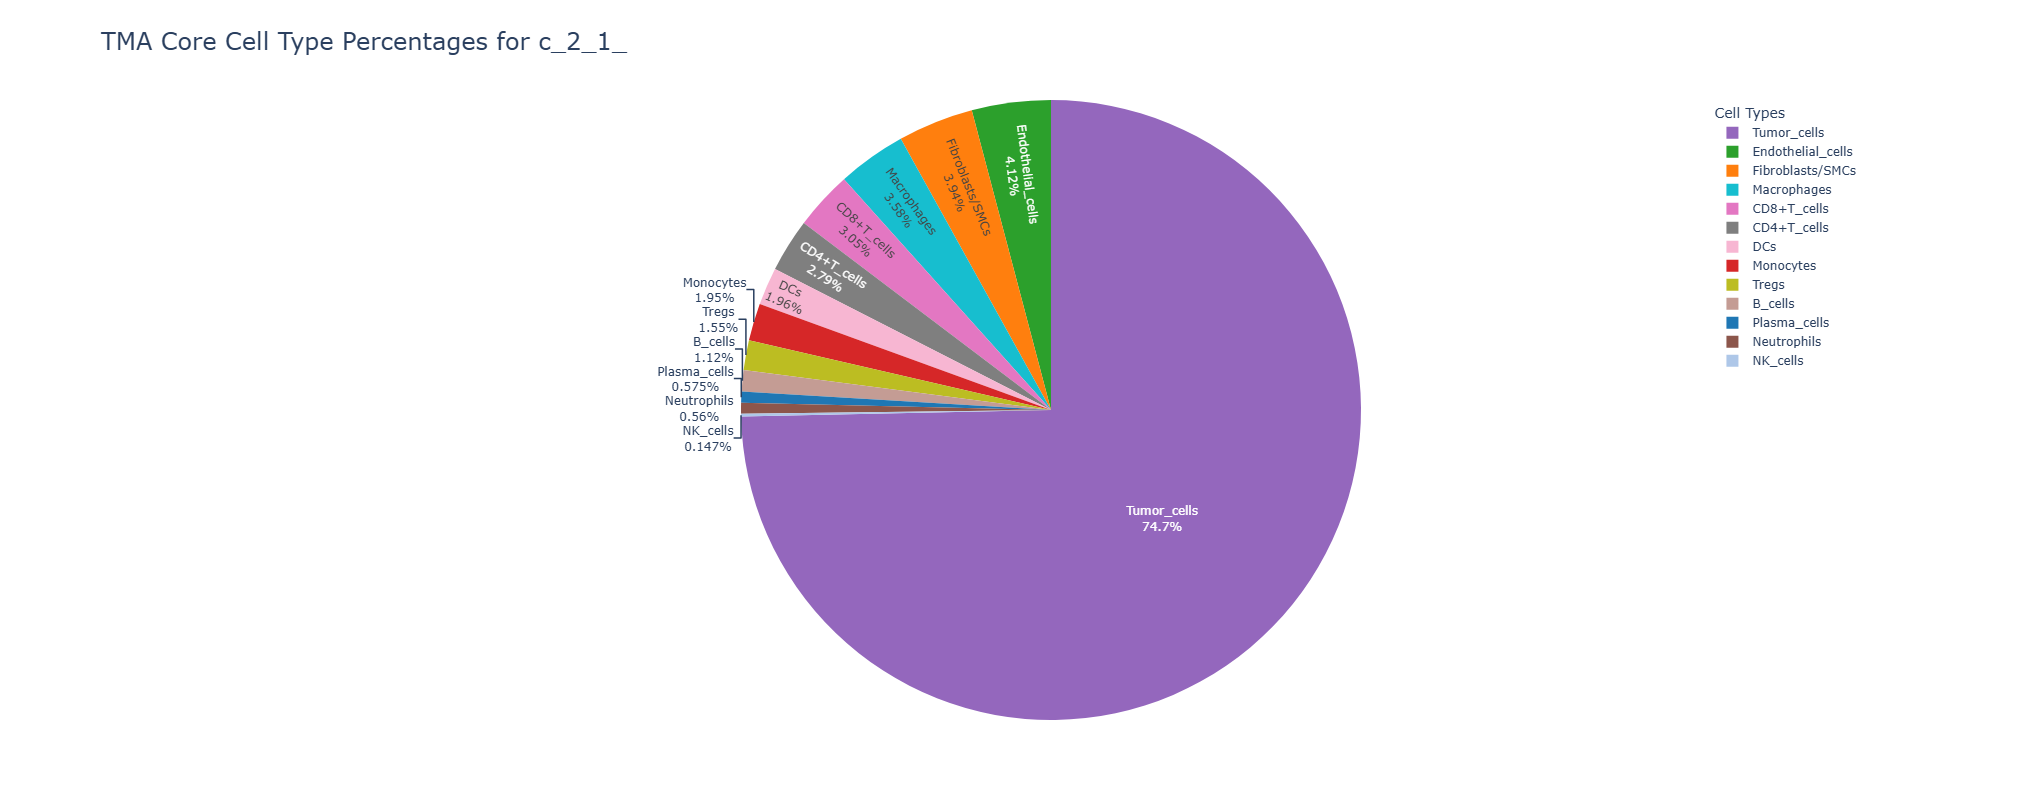

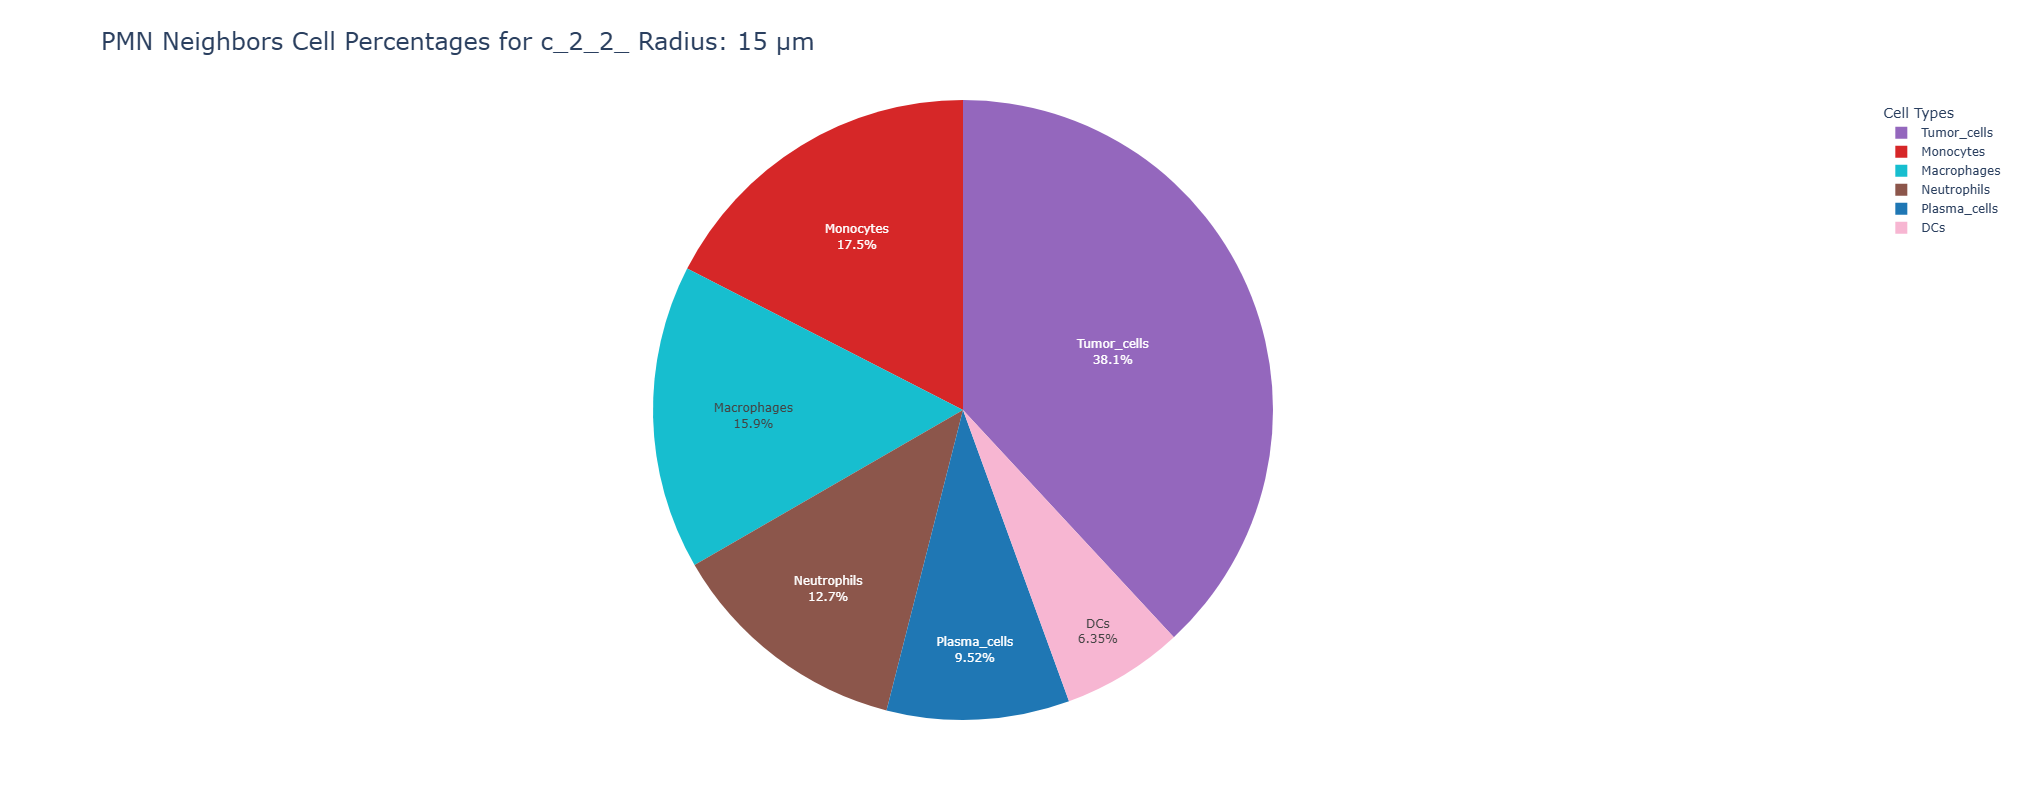

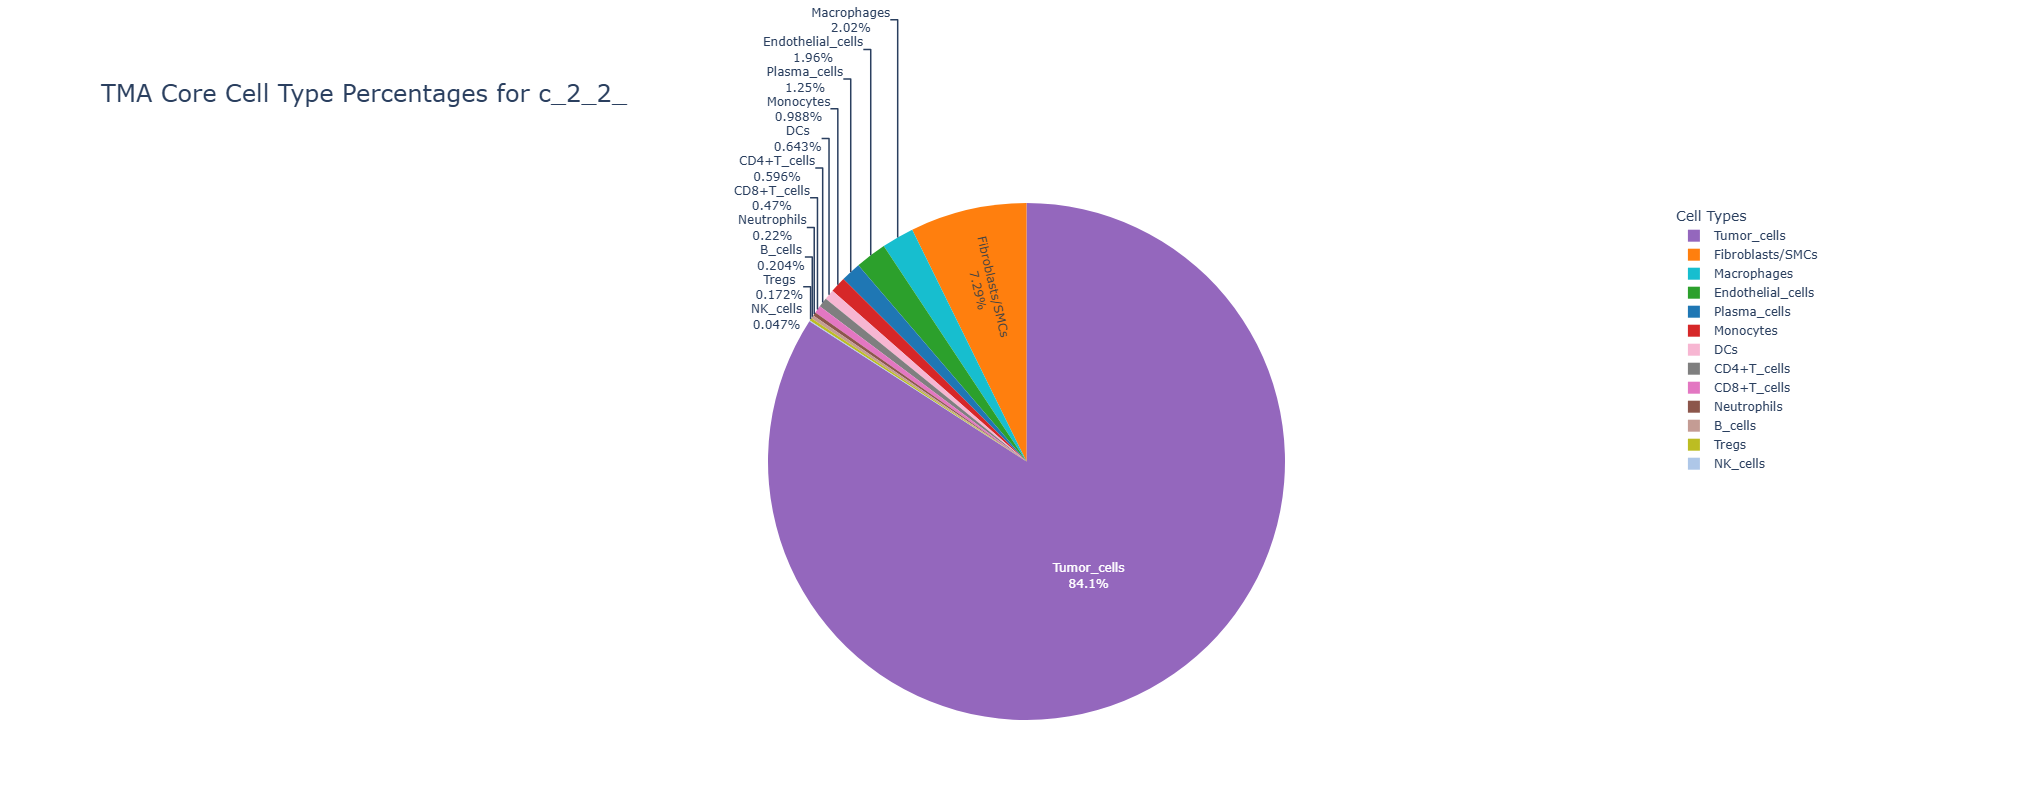

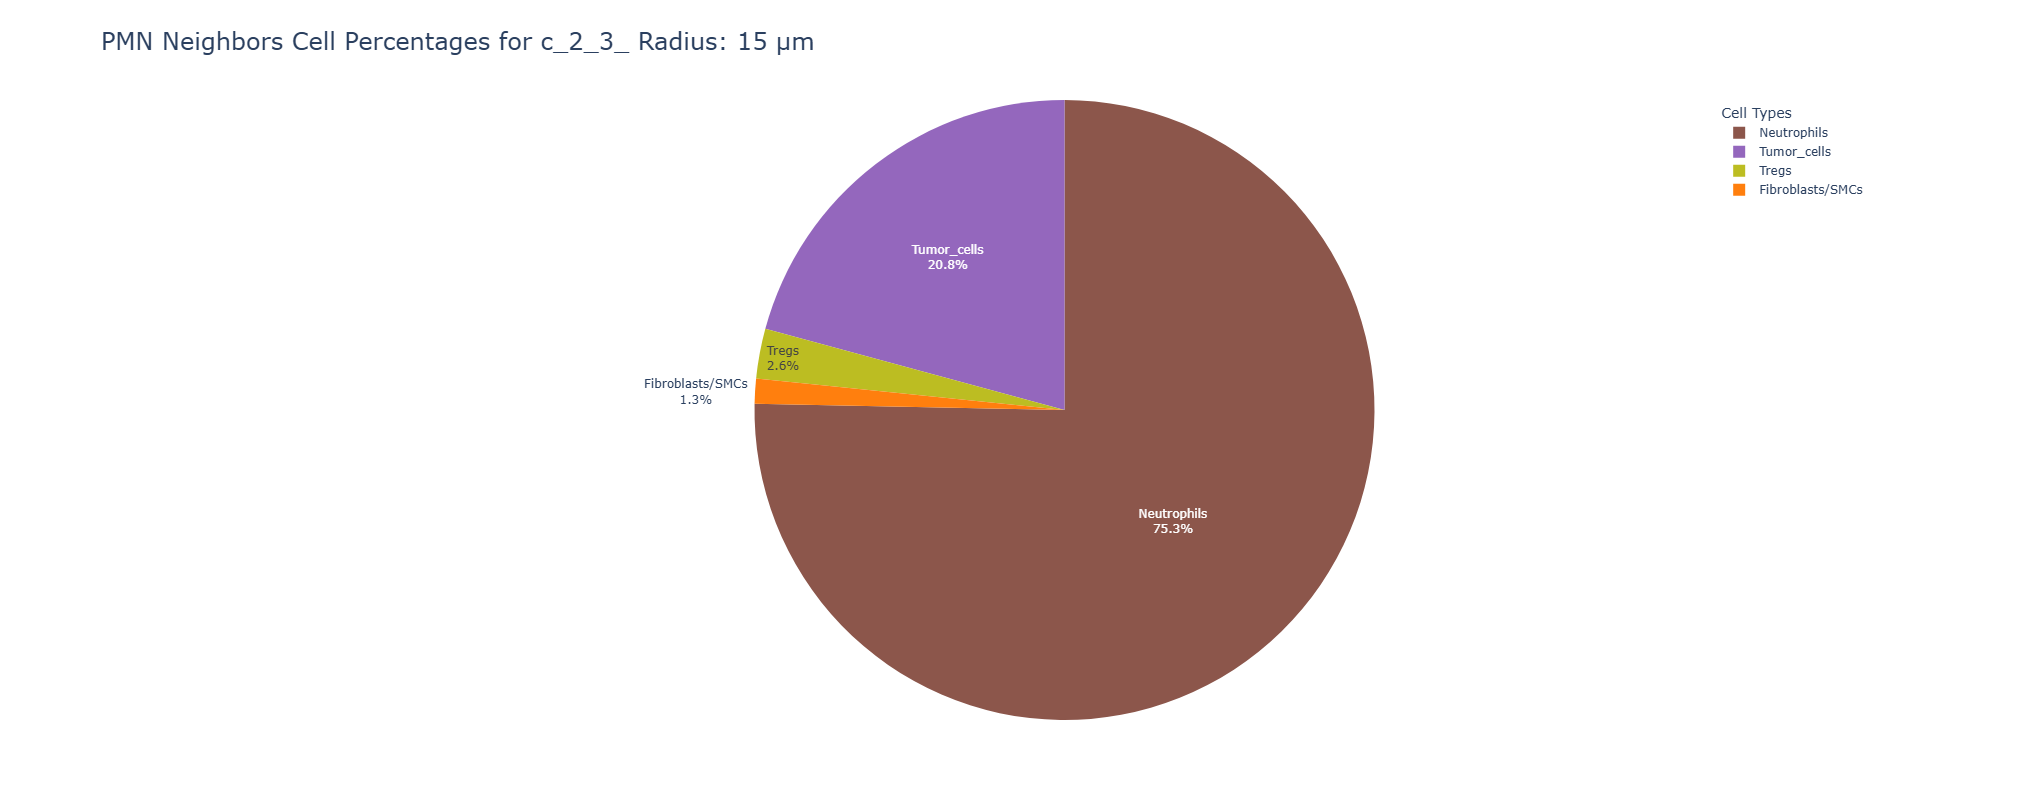

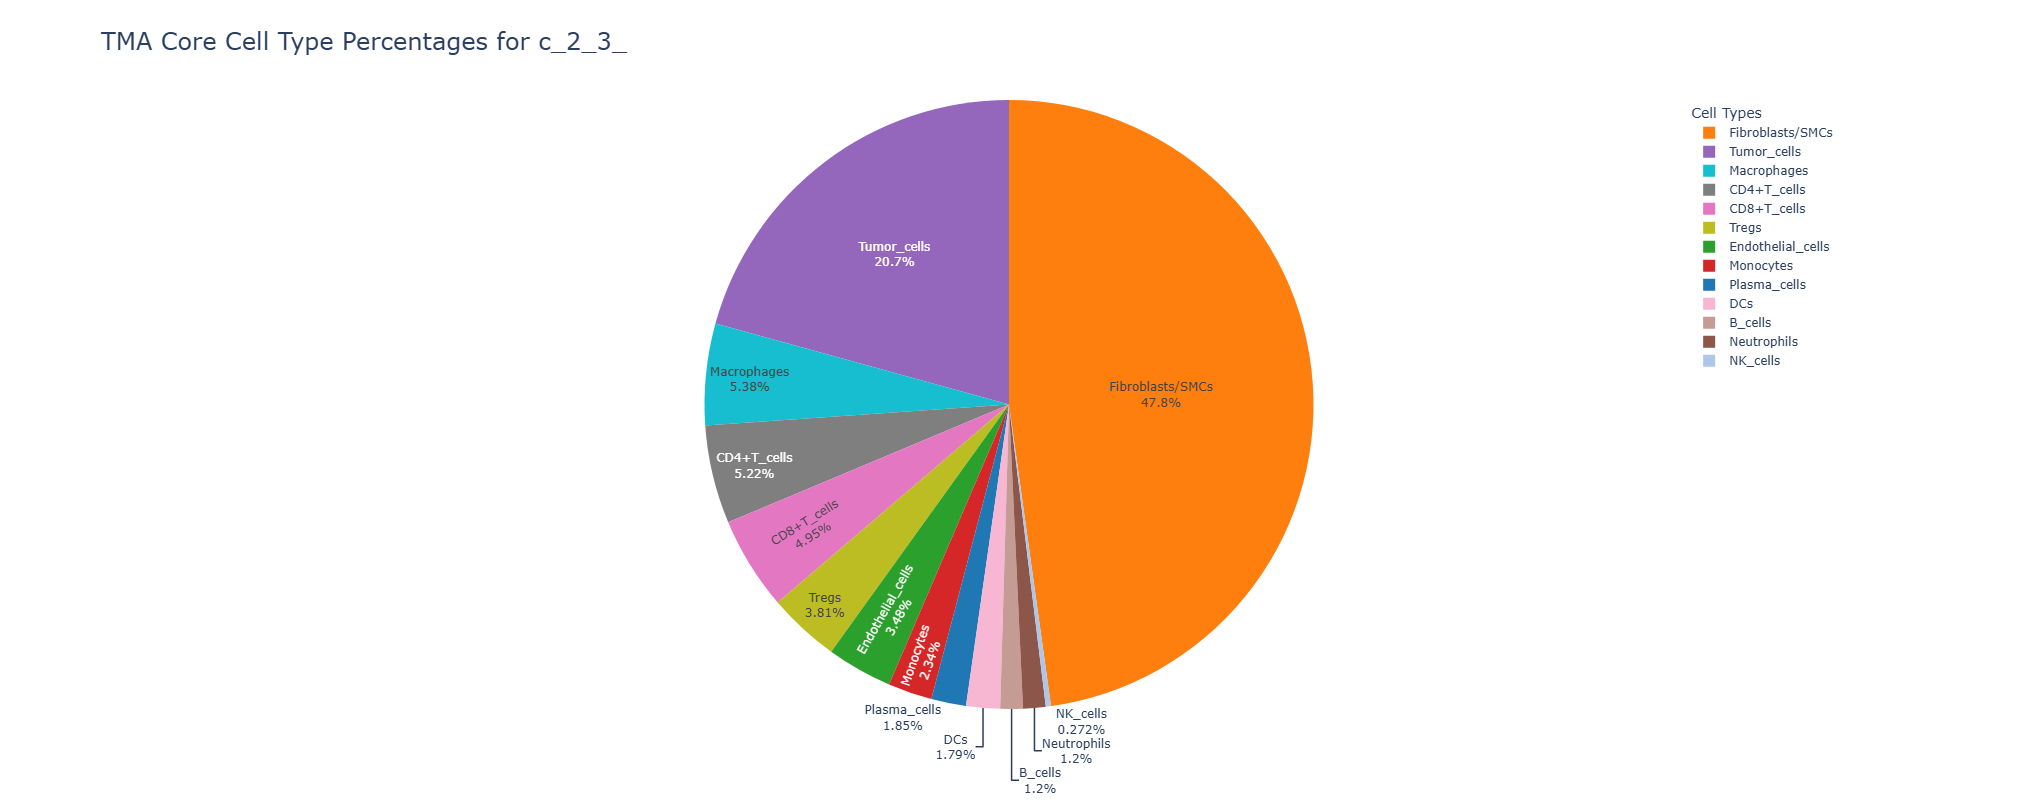

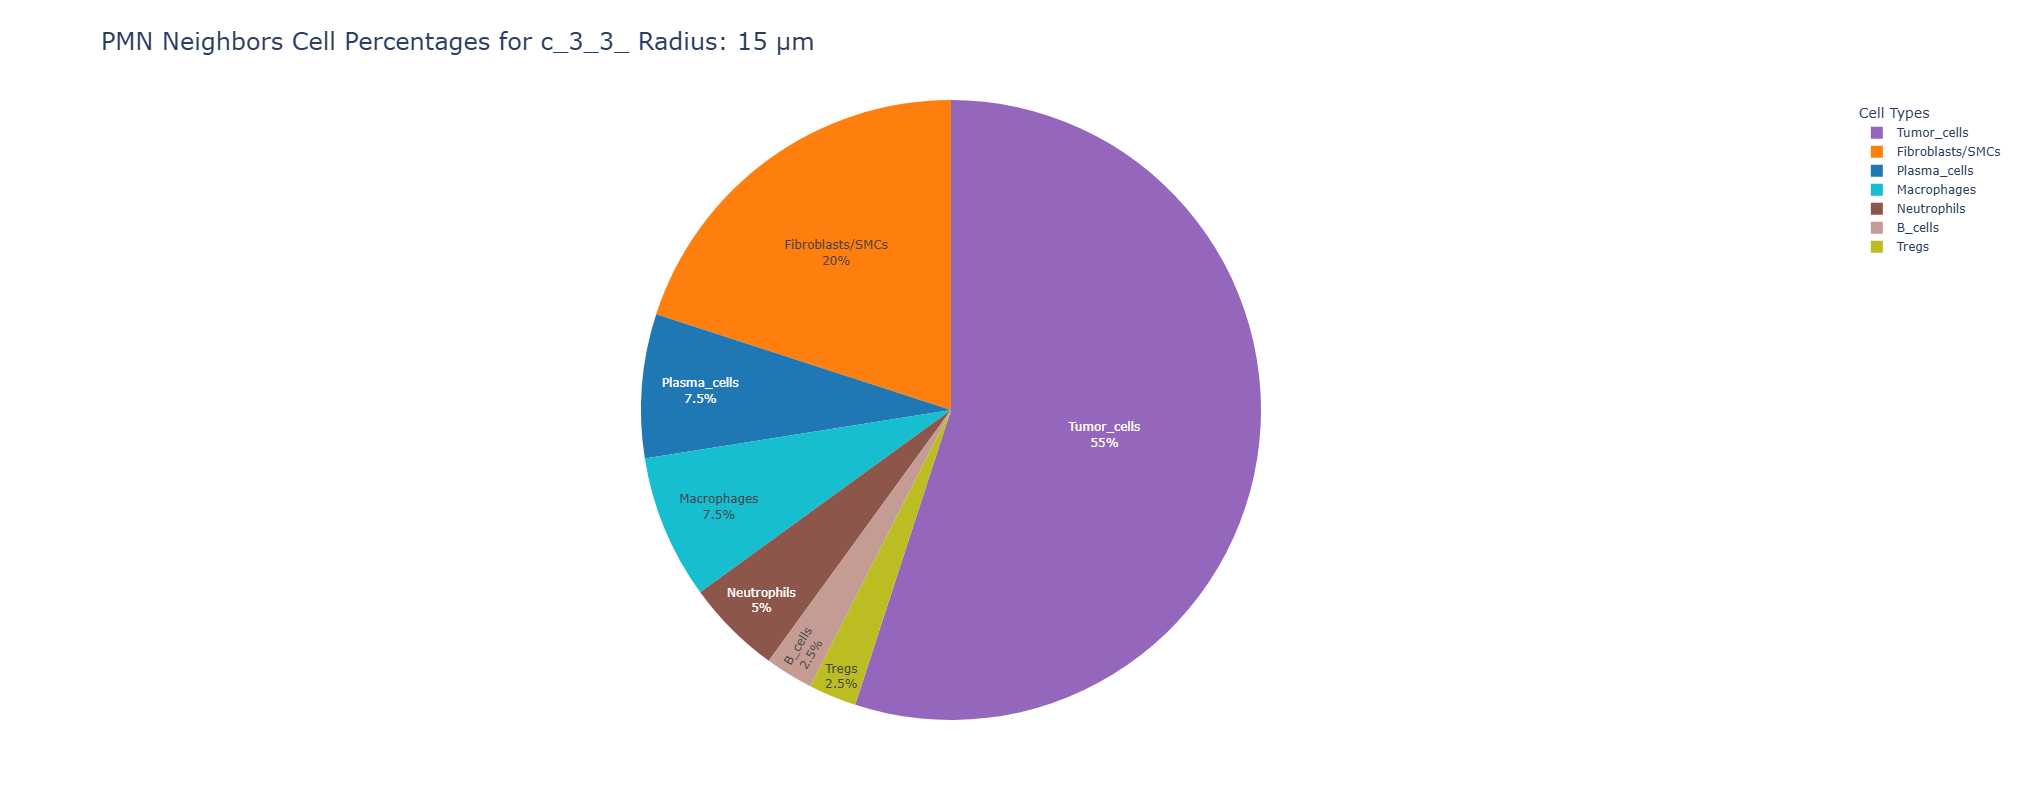

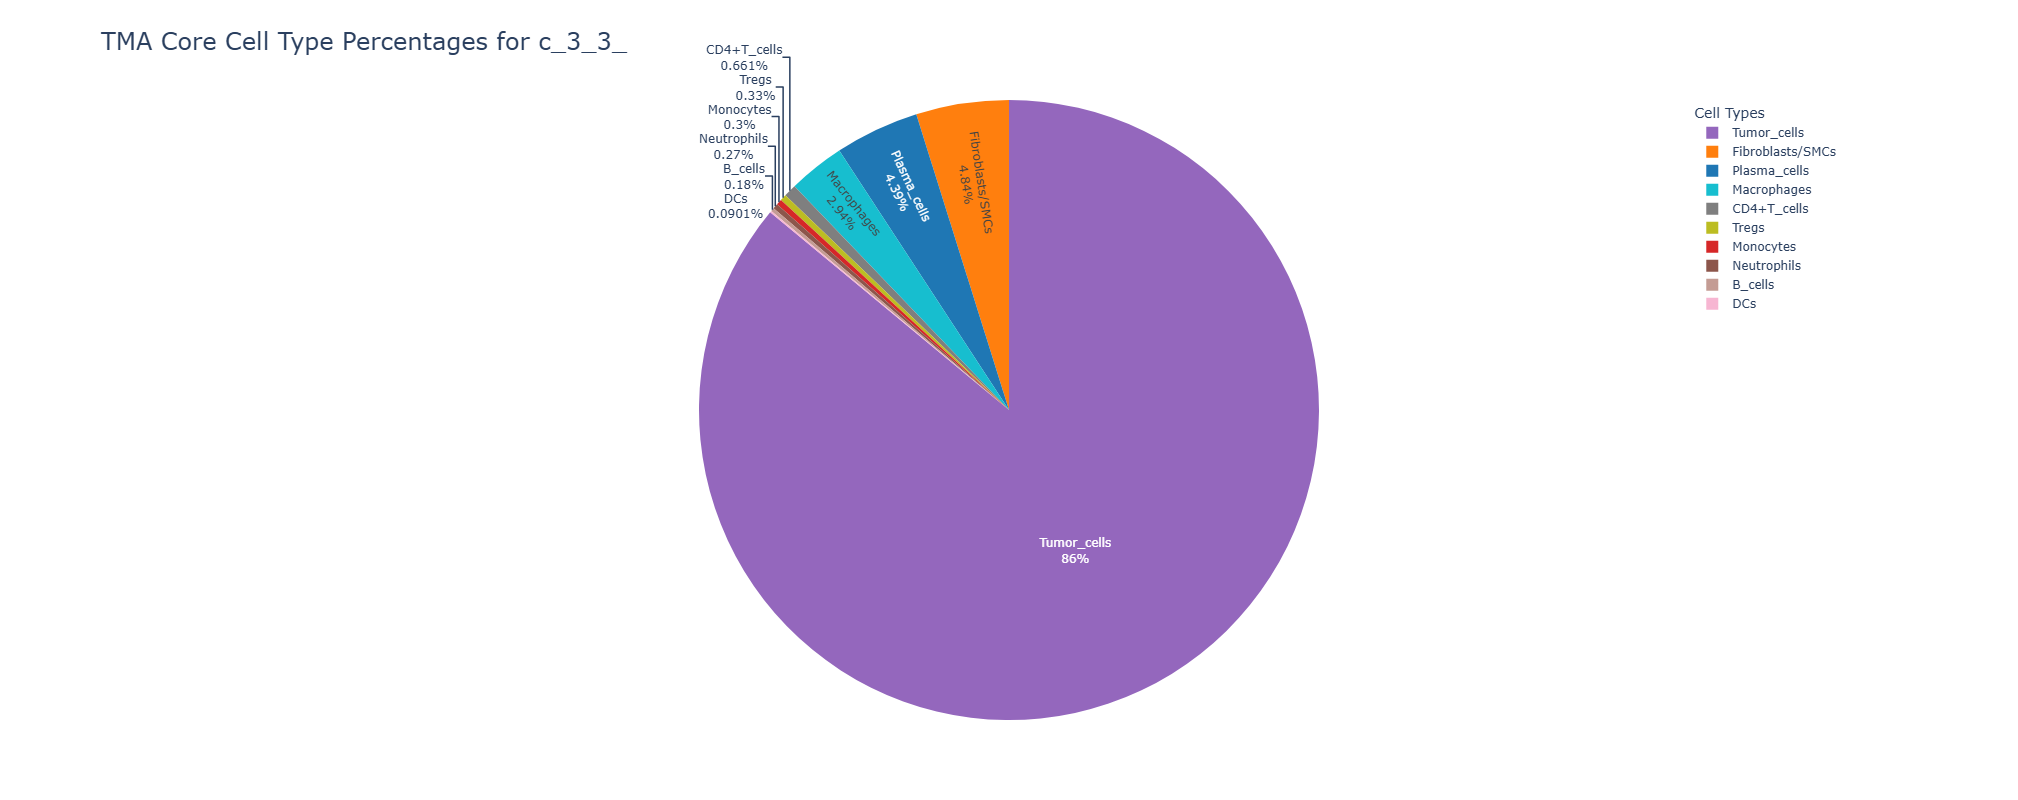

merged_annot_cluster,Tumor_cells,Fibroblasts/SMCs,Plasma_cells,Macrophages,CD4+T_cells,Tregs,Monocytes,Neutrophils,B_cells,DCs
c_3_3_,86.001802,4.836287,4.385701,2.943827,0.660859,0.33043,0.300391,0.270351,0.180234,0.090117


,Neutrophils,Endothelial_cells,Monocytes,Plasma_cells,Tumor_cells,Fibroblasts/SMCs,Macrophages,B_cells,CD4+T_cells,Total Cell Count,Tregs,CD8+T_cells,DCs
Sample ID,,,,,,,,,,,,,
c_1_1,142.0,125.0,9.0,50.0,98,19.0,4.0,2.0,2.0,451,0.0,0.0,0.0
c_1_3,0.0,14.0,1.0,2.0,13,6.0,0.0,0.0,1.0,38,1.0,0.0,0.0
c_2_1,20.0,0.0,16.0,8.0,82,24.0,4.0,4.0,5.0,184,1.0,9.0,11.0
c_2_2,8.0,0.0,11.0,6.0,24,0.0,10.0,0.0,0.0,63,0.0,0.0,4.0
c_2_3,58.0,0.0,0.0,0.0,16,1.0,0.0,0.0,0.0,77,2.0,0.0,0.0
c_3_3,2.0,0.0,0.0,3.0,22,8.0,3.0,1.0,0.0,40,1.0,0.0,0.0


In [137]:
import importlib
import my_functions

importlib.reload(my_functions)

CoLo_method="Radius"
radius=15

# Initialize an empty DataFrame to collect all percentage rows
all_percentages = pd.DataFrame()
all_total_counts = pd.DataFrame()

for i in range(1,4):
    for j in range(1,4):

        # Set Sample ID
        sample_id=f"c_{i}_{j}_"
        
        # check to make sure PMNs are present, skips if not present to prevent errors
        pmn_count=my_functions.pmn_counter(adata, f"c_{i}_{j}_")["PMN Count"]
        if pmn_count<1:
            continue

        # Calculate cell counts and percentages
        results = my_functions.average_cell_counts(adata, i, j, "radius",radius)
        #results = my_functions.average_cell_counts(adata, i, j, "delaunay",radius)

        # Append the percentage row to the overall DataFrame
        neighboring_percentages = pd.concat([all_percentages, results["Cell Type Percentages"]])
        all_total_counts = pd.concat([all_total_counts, results["Total Cell Counts"]])

        # Replaces Nans with 0 to pererve the numerical type of the matrix
        neighboring_percentages.fillna(0, inplace=True)
        all_total_counts.fillna(0, inplace=True)

        my_functions.plot_cell_type_pie(f"c_{i}_{j}",neighboring_percentages,f"PMN Neighbors Cell Percentages for {sample_id} Radius: {radius} μm")
        #my_functions.plot_cell_type_pie(f"c_{i}_{j}",neighboring_percentages,f"PMN Neighbors Cell Percentages for {sample_id} - Delaunay")

        #Display
        overall_percentages = my_functions.get_sample_cell_percentages(adata, sample_id)["Percentage Counts"]
        my_functions.plot_cell_type_pie(sample_id,overall_percentages, f"TMA Core Cell Type Percentages for {sample_id}")
        delta=neighboring_percentages-overall_percentages



display(overall_percentages)
display(all_total_counts)

#### Neighbooring Cell Matrix Creation - Output Matrix with % Neighboors for Entire Dataset

In [120]:
import my_functions
import pandas as pd

# Initialize collection DataFrames
all_total_counts_R = pd.DataFrame()
all_total_counts_NR = pd.DataFrame()
all_total_counts_R_percent = pd.DataFrame()
all_total_counts_NR_percent = pd.DataFrame()

# mininum number of pmn cells
pmn_floor=25
radius=15 # Radius in microns

for i in range(1, 4):
    for j in range(1, 26):
        sample_id = f"c_{i}_{j}_"
        pmn_count = my_functions.pmn_counter(adata, sample_id)["PMN Count"]
        if pmn_count <= pmn_floor:
            continue

        # Get results from your function
        results = my_functions.average_cell_counts(adata, i, j, "radius", radius)
        total_counts = results["Total Cell Counts"]

        # Extract total cell count value (from the "Total Cell Count" column)
        total_cell_count = total_counts["Total Cell Count"].values[0]

        # Drop that column before calculating percentages
        counts_no_total = total_counts.drop(columns=["Total Cell Count"])

        # Calculate percentages of each cell type
        percent_row = (counts_no_total / total_cell_count) * 100

        # Append to appropriate response group
        response = my_functions.get_sample_info(adata, sample_id)["Response"]
        if response == "R":
            all_total_counts_R = pd.concat([all_total_counts_R, total_counts])
            all_total_counts_R_percent = pd.concat([all_total_counts_R_percent, percent_row])
        elif response == "NR":
            all_total_counts_NR = pd.concat([all_total_counts_NR, total_counts])
            all_total_counts_NR_percent = pd.concat([all_total_counts_NR_percent, percent_row])

# Replace NaNs with 0 for safety
all_total_counts_R.fillna(0, inplace=True)
all_total_counts_NR.fillna(0, inplace=True)
all_total_counts_R_percent.fillna(0, inplace=True)
all_total_counts_NR_percent.fillna(0, inplace=True)

# Reorder Columns Alphabetically
all_total_counts_R_percent = all_total_counts_R_percent[sorted(all_total_counts_R_percent.columns)]
all_total_counts_NR_percent = all_total_counts_NR_percent[sorted(all_total_counts_NR_percent.columns)]

# Display
# display(all_total_counts_R)
display(all_total_counts_R_percent)
# display(all_total_counts_NR)
display(all_total_counts_NR_percent)

,B_cells,CD4+T_cells,CD8+T_cells,DCs,Endothelial_cells,Fibroblasts/SMCs,Macrophages,Monocytes,NK_cells,Neutrophils,Plasma_cells,Tregs,Tumor_cells
Sample ID,,,,,,,,,,,,,
c_1_1,0.443459,0.443459,0.000000,0.000000,27.716186,4.212860,0.886918,1.995565,0.000000,31.485588,11.086475,0.000000,21.729490
c_1_11,3.030303,3.787879,2.777778,5.303030,0.000000,13.131313,14.646465,11.363636,0.000000,14.646465,4.797980,1.010101,25.505051
c_1_12,0.787402,10.236220,4.724409,5.511811,0.000000,11.811024,9.448819,2.362205,0.000000,9.448819,3.149606,0.787402,41.732283
c_1_13,0.000000,4.666667,0.000000,8.000000,0.000000,8.000000,1.333333,4.666667,0.000000,40.000000,0.000000,1.333333,32.000000
c_1_16,1.570681,6.806283,8.376963,6.806283,0.000000,25.654450,14.136126,6.806283,0.000000,5.235602,15.706806,3.141361,5.759162
c_1_20,0.000000,2.415459,0.000000,1.932367,0.483092,13.043478,3.864734,3.381643,0.483092,27.053140,3.864734,0.000000,43.478261
c_1_21,1.439758,2.475373,6.339985,8.385956,0.000000,3.738318,9.876231,5.430664,0.202071,47.941399,3.738318,1.035615,9.396312
c_1_24,0.570125,1.824401,0.228050,11.516534,0.000000,3.648803,2.736602,0.798176,0.000000,62.713797,0.114025,0.228050,15.621437
c_2_4,3.906250,10.156250,15.625000,8.593750,0.000000,15.625000,13.281250,4.687500,0.781250,3.125000,6.250000,4.687500,13.281250


,B_cells,CD4+T_cells,CD8+T_cells,DCs,Endothelial_cells,Fibroblasts/SMCs,Macrophages,Monocytes,NK_cells,Neutrophils,Plasma_cells,Tregs,Tumor_cells
Sample ID,,,,,,,,,,,,,
c_1_8,0.641026,0.641026,2.564103,1.923077,54.487179,0.641026,20.512821,3.205128,0.641026,6.410256,3.205128,0.000000,5.128205
c_1_9,0.000000,0.000000,0.000000,2.727273,0.000000,7.272727,3.636364,2.727273,0.000000,41.818182,0.000000,0.000000,41.818182
c_1_17,0.000000,7.317073,1.829268,23.170732,0.000000,9.756098,2.439024,2.439024,0.000000,25.609756,10.365854,2.439024,14.634146
c_1_18,0.611845,3.034753,3.426334,2.178169,0.000000,14.390602,5.996084,6.656877,0.000000,44.395497,3.157122,0.783162,15.369555
c_1_19,0.414508,1.347150,1.528497,7.202073,0.000000,13.186528,8.704663,9.585492,0.025907,34.818653,2.098446,0.336788,20.751295
c_1_22,1.754386,5.263158,7.017544,7.268170,0.000000,19.047619,4.761905,4.761905,0.000000,22.556391,3.007519,1.253133,23.308271
c_1_23,0.000000,0.000000,0.000000,0.000000,0.000000,22.051282,8.717949,0.000000,0.000000,22.564103,1.025641,0.000000,45.641026
c_1_25,3.978780,13.262599,13.527851,14.588859,0.000000,11.936340,10.875332,5.305040,0.265252,12.732095,7.161804,1.061008,5.305040
c_2_1,2.173913,2.717391,4.891304,5.978261,0.000000,13.043478,2.173913,8.695652,0.000000,10.869565,4.347826,0.543478,44.565217


### Creating Percentage Plots of Neighborhood 

Each sample has a cellular neighborhood around the PMNs. We hope to compare this neighborhood between R and NR groups to see if there is a signficant difference. This is likely to lead to a highly variable response

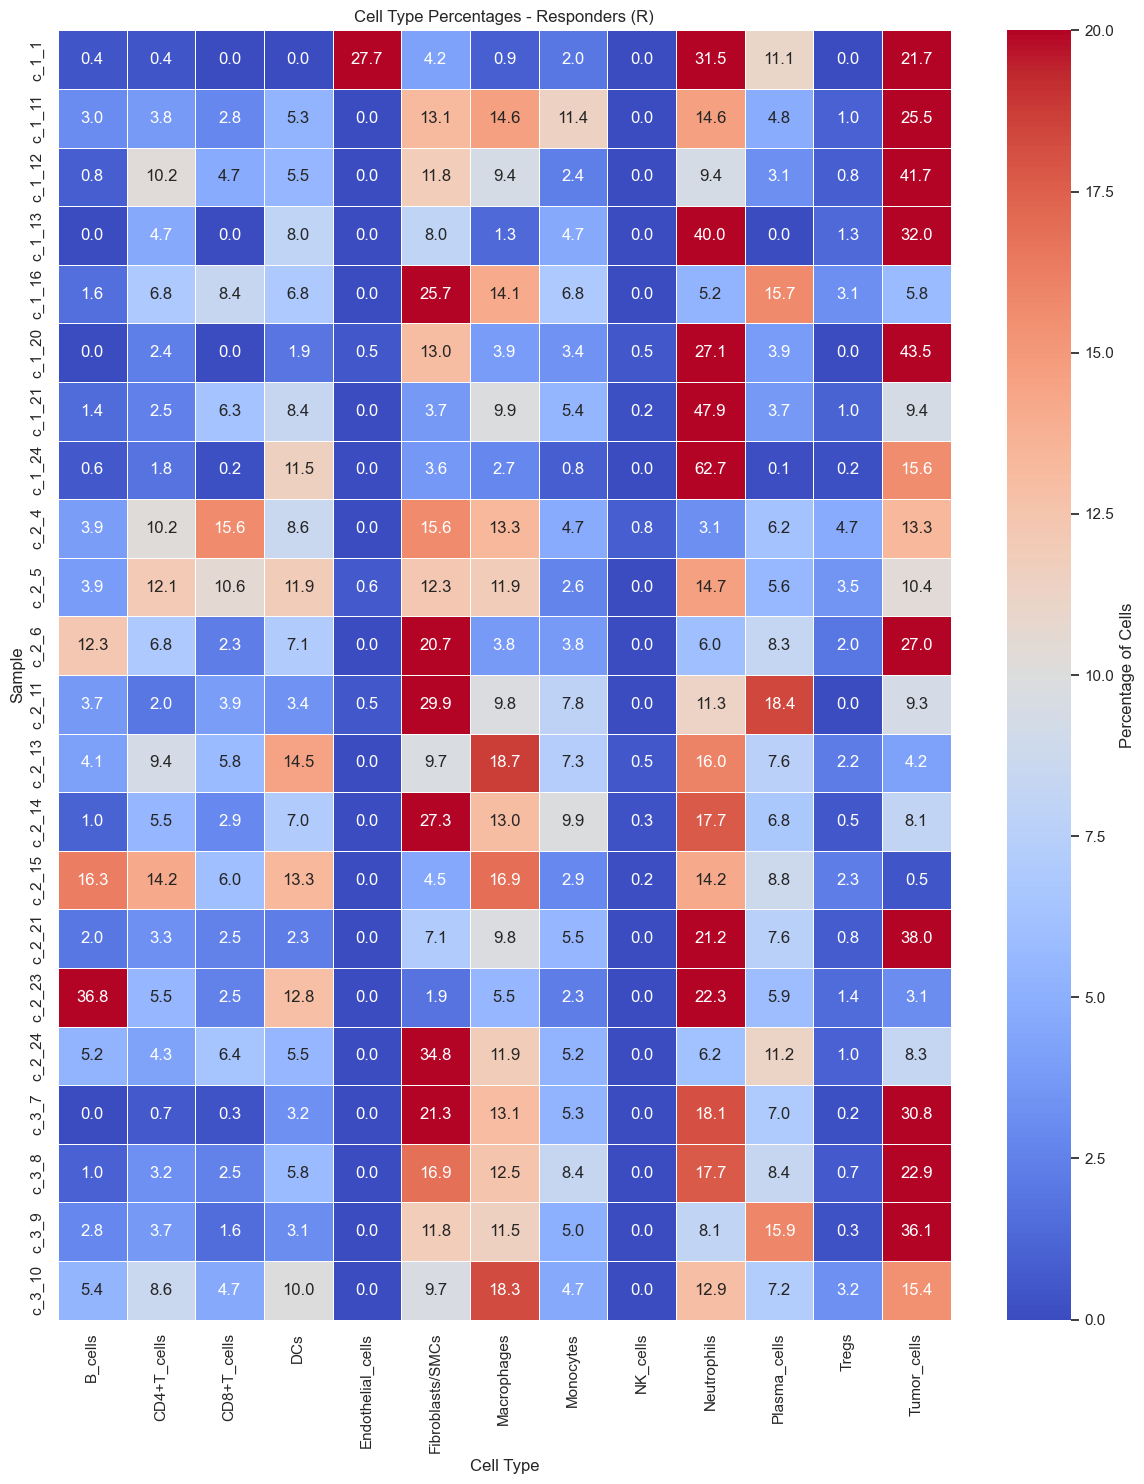

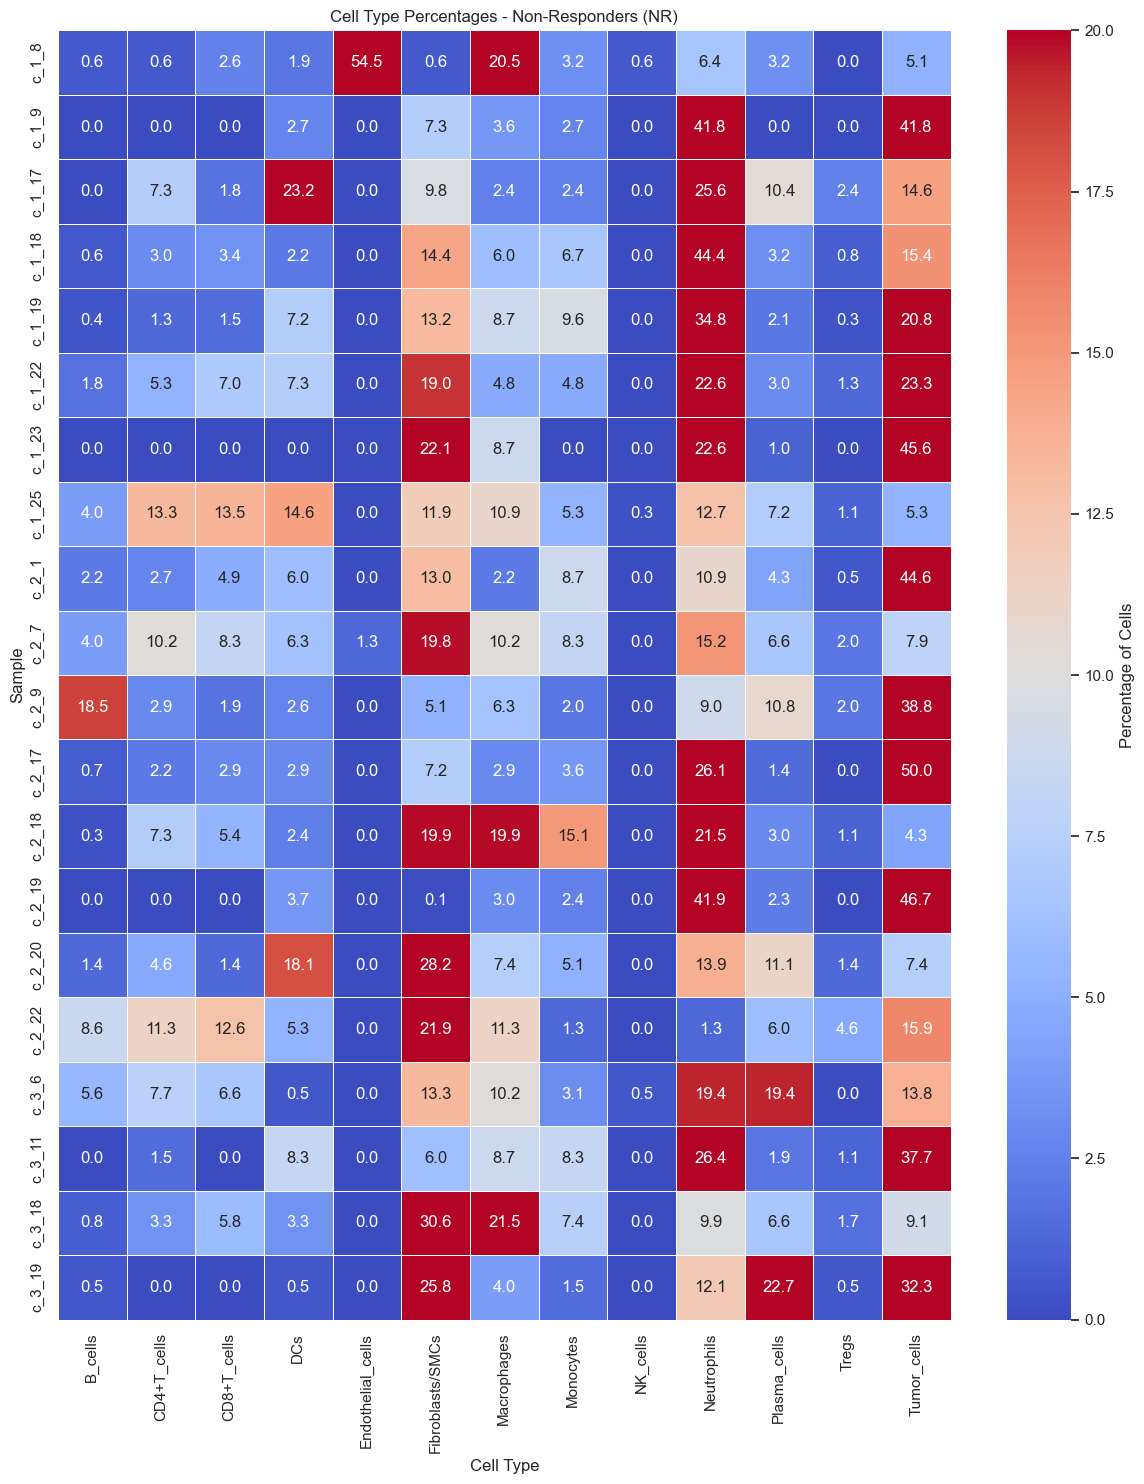

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: Set Seaborn styling
sns.set(style="whitegrid")

# Create the heatmap
plt.figure(figsize=(12, 15))  # adjust size as needed
sns.heatmap(
    all_total_counts_R_percent,
    cmap="coolwarm",        # or "magma", "coolwarm", etc.
    annot=True,            # shows the % values in cells
    fmt=".1f",             # one decimal place
    cbar_kws={'label': 'Percentage of Cells'},
    vmin=0,
    vmax=20,
    linewidths=0.5         # optional: adds grid lines
)
plt.title("Cell Type Percentages - Responders (R)")
plt.xlabel("Cell Type")
plt.ylabel("Sample")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 15))
sns.heatmap(
    all_total_counts_NR_percent,
    cmap="coolwarm",
    annot=True,
    fmt=".1f",
    cbar_kws={'label': 'Percentage of Cells'},
    vmin=0,
    vmax=20,
    linewidths=0.5
)
plt.title("Cell Type Percentages - Non-Responders (NR)")
plt.xlabel("Cell Type")
plt.ylabel("Sample")
plt.tight_layout()
plt.show()

# Responder and Non-Responder Cell Neighboors Pie Chart

I want to see how the cellular neighborhood differs between responder and non responder cells. The z-scores were non conclusive and there is likely heavy tissue differences making statistical analysis hard but it will be a useful visual.

#### Get Raw Counts

In [78]:
import my_functions

# Initialize an empty DataFrame to collect all percentage rows
all_percentages = pd.DataFrame()
all_total_counts_R = pd.DataFrame()
all_total_counts_NR = pd.DataFrame()

radius=30 # radial distance um
for i in range(1,4):
    for j in range(1,26):

        # check to make sure PMNs are present, skips if not present to prevent errors
        pmn_count=my_functions.pmn_counter(adata, f"c_{i}_{j}_")["PMN Count"]
        if pmn_count<1:
            continue

        # Calculate cell counts and percentages
        results = my_functions.average_cell_counts(adata, i, j, "radius", radius)
       # results = my_functions.average_cell_counts(adata, i, j, "delaunay", 125)
    
        # Append the percentage row to the overall DataFrame
        if my_functions.get_sample_info(adata,f"c_{i}_{j}_")["Response"]=="R":
            all_total_counts_R = pd.concat([all_total_counts_R, results["Total Cell Counts"]])
        elif my_functions.get_sample_info(adata,f"c_{i}_{j}_")["Response"]=="NR":
            all_total_counts_NR = pd.concat([all_total_counts_NR, results["Total Cell Counts"]])

        # Replaces Nans with 0 to pererve the numerical type of the matrix
        all_total_counts_R.fillna(0, inplace=True)
        all_total_counts_NR.fillna(0, inplace=True)
        

#display(all_percentages)
display(all_total_counts_R)
display(all_total_counts_NR)

,Endothelial_cells,Neutrophils,Plasma_cells,Tumor_cells,Fibroblasts/SMCs,Monocytes,B_cells,Macrophages,CD4+T_cells,Total Cell Count,Tregs,DCs,CD8+T_cells,NK_cells
Sample ID,,,,,,,,,,,,,,
c_1_1,555.0,316.0,112,390,147,26.0,4.0,16.0,2.0,1568,0.0,0.0,0.0,0.0
c_1_3,57.0,2.0,5,54,27,2.0,0.0,3.0,5.0,156,1.0,0.0,0.0,0.0
c_1_4,149.0,10.0,7,19,19,3.0,7.0,3.0,12.0,245,6.0,10.0,0.0,0.0
c_1_5,86.0,18.0,17,70,72,7.0,0.0,7.0,0.0,288,6.0,2.0,3.0,0.0
c_1_6,124.0,124.0,91,39,95,0.0,7.0,0.0,34.0,522,8.0,0.0,0.0,0.0
c_1_10,0.0,4.0,11,28,120,0.0,0.0,7.0,5.0,175,0.0,0.0,0.0,0.0
c_1_11,0.0,174.0,88,477,210,186.0,34.0,264.0,79.0,1680,14.0,96.0,58.0,0.0
c_1_12,0.0,48.0,23,253,70,15.0,23.0,44.0,37.0,593,14.0,20.0,46.0,0.0
c_1_13,0.0,168.0,3,234,56,14.0,4.0,28.0,24.0,576,7.0,36.0,2.0,0.0


,Fibroblasts/SMCs,Endothelial_cells,Plasma_cells,Tumor_cells,Monocytes,Neutrophils,Total Cell Count,CD8+T_cells,CD4+T_cells,Tregs,Macrophages,DCs,NK_cells,B_cells
Sample ID,,,,,,,,,,,,,,
c_1_7,5,29.0,2.0,40,1,4,81,0.0,0.0,0.0,0.0,0.0,0.0,0.0
c_1_8,10,291.0,11.0,22,15,16,537,23.0,4.0,1.0,124.0,14.0,4.0,2.0
c_1_9,48,0.0,10.0,212,14,80,403,1.0,3.0,0.0,26.0,8.0,0.0,1.0
c_1_17,69,2.0,83.0,102,18,86,610,6.0,36.0,13.0,33.0,158.0,0.0,4.0
c_1_18,2379,0.0,385.0,3328,870,4230,13732,494.0,523.0,119.0,1028.0,265.0,0.0,111.0
c_1_19,1655,0.0,337.0,4662,1140,3238,14054,274.0,202.0,56.0,1406.0,1010.0,8.0,66.0
c_1_22,345,0.0,54.0,458,81,234,1599,97.0,111.0,17.0,103.0,81.0,1.0,17.0
c_1_23,141,0.0,2.0,408,6,132,729,0.0,0.0,0.0,40.0,0.0,0.0,0.0
c_1_25,210,0.0,145.0,102,97,134,1704,203.0,211.0,31.0,226.0,262.0,3.0,80.0


#### Add Total And Percentage Row to Raw Count Rows (Responder and Non Responder Groups)

In [79]:
# Drop 'Total Cell Count' column before calculating totals
all_total_counts_R = all_total_counts_R.drop("Total Cell Count", axis=1)
all_total_counts_NR = all_total_counts_NR.drop("Total Cell Count", axis=1)

# Create totals row (summing numeric columns)
totals_R = all_total_counts_R.sum(numeric_only=True)
totals_NR = all_total_counts_NR.sum(numeric_only=True)
totals_R.name = 'Total'  # Name the row index
totals_NR.name = 'Total'  # Name the row index

# Append the totals row to the original DataFrame
all_total_counts_R = pd.concat([all_total_counts_R, totals_R.to_frame().T])
all_total_counts_NR = pd.concat([all_total_counts_NR, totals_NR.to_frame().T])

# Create percent row: each column’s value as a percent of the grand total
percent_R = (totals_R / totals_R.sum()) * 100
percent_NR = (totals_NR / totals_NR.sum()) * 100
percent_R.name = 'Percent Responder'
percent_NR.name = 'Percent Non Responder'

# Round to 1 decimal place (optional)
percent_R = percent_R.round(3)
percent_NR = percent_NR.round(3)

# Append percent row
all_total_counts_R = pd.concat([all_total_counts_R, percent_R.to_frame().T])
all_total_counts_NR = pd.concat([all_total_counts_NR, percent_NR.to_frame().T])

# Display results
display(all_total_counts_R)
display(all_total_counts_NR)

,Endothelial_cells,Neutrophils,Plasma_cells,Tumor_cells,Fibroblasts/SMCs,Monocytes,B_cells,Macrophages,CD4+T_cells,Tregs,DCs,CD8+T_cells,NK_cells
c_1_1,555.000,316.000,112.000,390.000,147.000,26.000,4.000,16.000,2.000,0.00,0.000,0.000,0.000
c_1_3,57.000,2.000,5.000,54.000,27.000,2.000,0.000,3.000,5.000,1.00,0.000,0.000,0.000
c_1_4,149.000,10.000,7.000,19.000,19.000,3.000,7.000,3.000,12.000,6.00,10.000,0.000,0.000
c_1_5,86.000,18.000,17.000,70.000,72.000,7.000,0.000,7.000,0.000,6.00,2.000,3.000,0.000
c_1_6,124.000,124.000,91.000,39.000,95.000,0.000,7.000,0.000,34.000,8.00,0.000,0.000,0.000
c_1_10,0.000,4.000,11.000,28.000,120.000,0.000,0.000,7.000,5.000,0.00,0.000,0.000,0.000
c_1_11,0.000,174.000,88.000,477.000,210.000,186.000,34.000,264.000,79.000,14.00,96.000,58.000,0.000
c_1_12,0.000,48.000,23.000,253.000,70.000,15.000,23.000,44.000,37.000,14.00,20.000,46.000,0.000
c_1_13,0.000,168.000,3.000,234.000,56.000,14.000,4.000,28.000,24.000,7.00,36.000,2.000,0.000
c_1_14,0.000,0.000,1.000,9.000,30.000,9.000,0.000,4.000,6.000,0.00,1.000,0.000,0.000


,Fibroblasts/SMCs,Endothelial_cells,Plasma_cells,Tumor_cells,Monocytes,Neutrophils,CD8+T_cells,CD4+T_cells,Tregs,Macrophages,DCs,NK_cells,B_cells
c_1_7,5.000,29.000,2.000,40.000,1.00,4.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
c_1_8,10.000,291.000,11.000,22.000,15.00,16.000,23.000,4.000,1.000,124.000,14.000,4.000,2.000
c_1_9,48.000,0.000,10.000,212.000,14.00,80.000,1.000,3.000,0.000,26.000,8.000,0.000,1.000
c_1_17,69.000,2.000,83.000,102.000,18.00,86.000,6.000,36.000,13.000,33.000,158.000,0.000,4.000
c_1_18,2379.000,0.000,385.000,3328.000,870.00,4230.000,494.000,523.000,119.000,1028.000,265.000,0.000,111.000
c_1_19,1655.000,0.000,337.000,4662.000,1140.00,3238.000,274.000,202.000,56.000,1406.000,1010.000,8.000,66.000
c_1_22,345.000,0.000,54.000,458.000,81.00,234.000,97.000,111.000,17.000,103.000,81.000,1.000,17.000
c_1_23,141.000,0.000,2.000,408.000,6.00,132.000,0.000,0.000,0.000,40.000,0.000,0.000,0.000
c_1_25,210.000,0.000,145.000,102.000,97.00,134.000,203.000,211.000,31.000,226.000,262.000,3.000,80.000
c_2_1,89.000,3.000,13.000,446.000,59.00,56.000,19.000,21.000,6.000,28.000,22.000,2.000,10.000


#### Display Pie Chart of PMN Neighboor Hood for Responder Groups

[NbConvertApp] Converting notebook my_functions.ipynb to python
[NbConvertApp] Writing 24127 bytes to my_functions.py


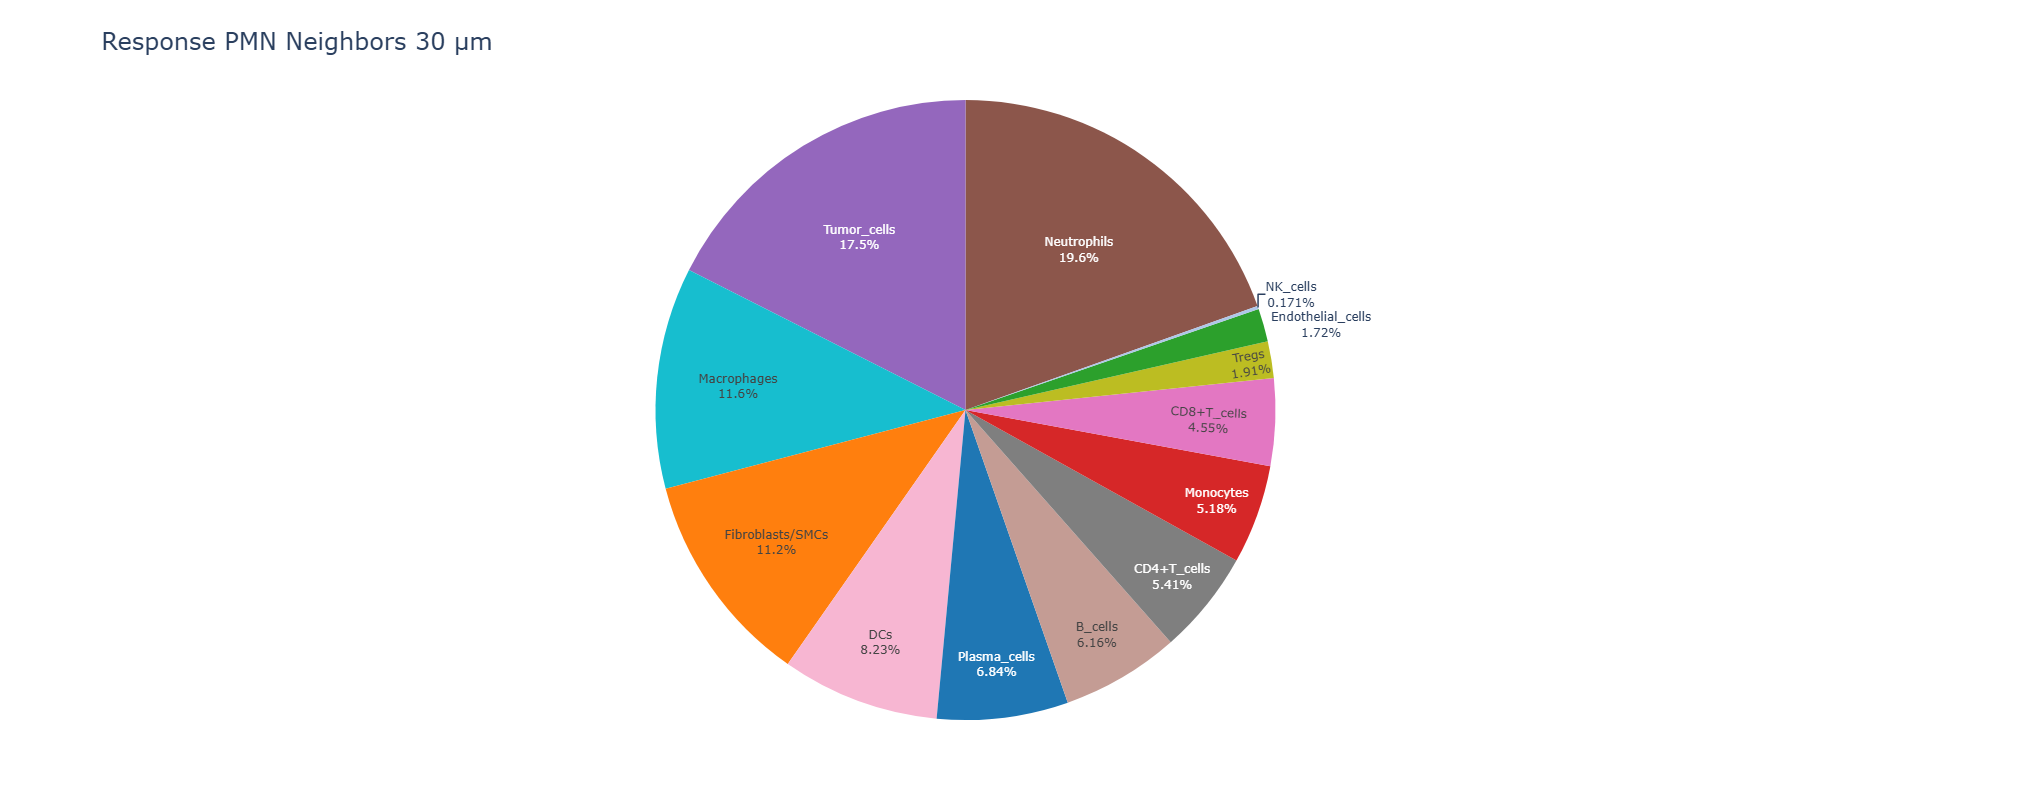

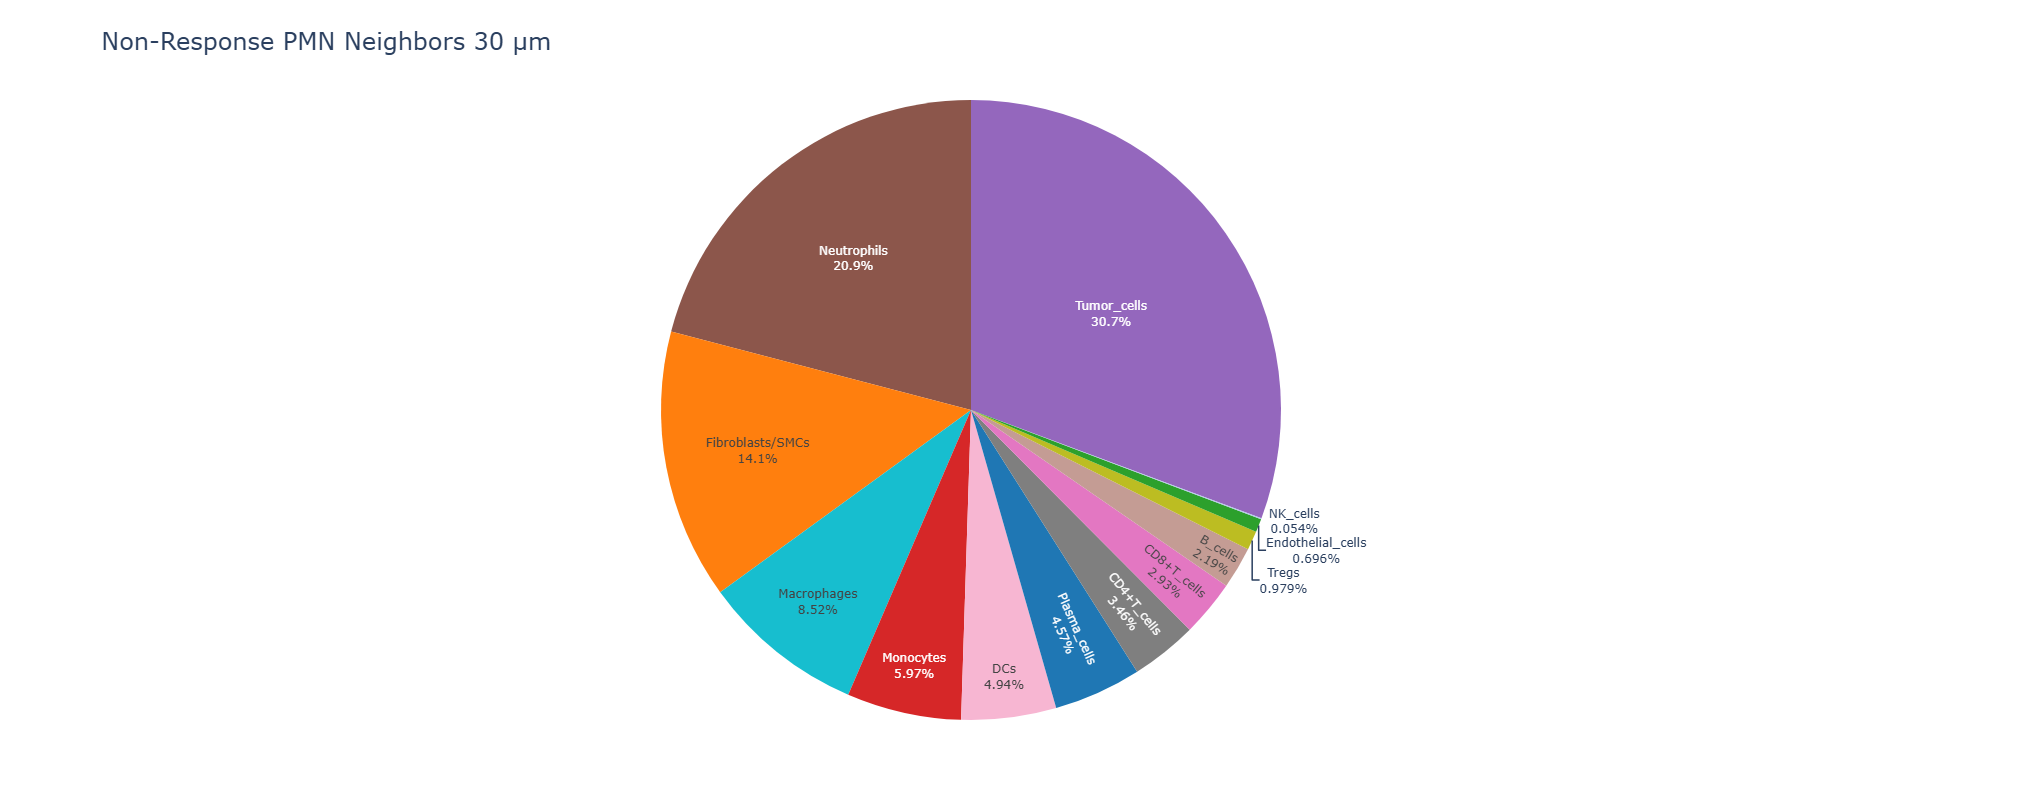

In [80]:
import importlib
import my_functions

importlib.reload(my_functions)

my_functions.plot_cell_type_pie("Percent Responder",all_total_counts_R,f"Response PMN Neighbors {radius} µm",800,800,False,False)
my_functions.plot_cell_type_pie("Percent Non Responder",all_total_counts_NR,f"Non-Response PMN Neighbors {radius} µm",800,800,False,False)

### Overall Sample Cell Type Percentages

Goals: creat a function which finds the overall % of cell types in a sample given a sample id. Put the result in my_functions

In [22]:
import importlib
import my_functions

importlib.reload(my_functions)

percentages = my_functions.get_sample_cell_percentages(adata, "c_1_3")["Percentage Counts"]

display(percentages)
sample_id="c_1_1"
pmn_floor=25
for i in range(1,4):
    for j in range(1,26):
        pmn_count = my_functions.pmn_counter(adata, sample_id)["PMN Count"]
        if pmn_count <= pmn_floor:
            continue
        percentages = my_functions.get_sample_cell_percentages(adata, sample_id)["Percentage Counts"]


[NbConvertApp] Converting notebook my_functions.ipynb to python
[NbConvertApp] Writing 24140 bytes to my_functions.py


merged_annot_cluster,Endothelial_cells,Tumor_cells,Fibroblasts/SMCs,Plasma_cells,Macrophages,CD4+T_cells,DCs,CD8+T_cells,Monocytes,B_cells,Neutrophils,Tregs,NK_cells
c_1_3_,39.428474,38.424902,19.918353,0.612349,0.306175,0.306175,0.238136,0.238136,0.170097,0.136078,0.102058,0.085048,0.034019


## Detla Matrix Creation

Comparing the cellular neighbors between R and NR groups is compliated by the fact that the groups may have different overall composition. For example NR PMN cells are more likely to be near tumor cells than R. Is that because of the tumor-PMN iteraction or because NR have more tumor cells in general. 

This calls a funct to get the overall cell percentage.

Diff that with another matrix.

#### Overal Cell Type Matrix

In [26]:
import importlib
import my_functions
import pandas as pd

importlib.reload(my_functions)

def get_cell_type_percentages(adata):

    #initialize output
    output_percent_R=pd.DataFrame()
    output_percent_NR=pd.DataFrame()
    output_percent=pd.DataFrame()
    pmn_floor=25

    # Iterate through 
    for i in range(1,4):
        for j in range(1,26):

            #Set sample Id in format
            sample_id=f"c_{i}_{j}_"
            pmn_count = my_functions.pmn_counter(adata, sample_id)["PMN Count"]
            # Pmn floor is typically 25
            if pmn_count <= pmn_floor:
                continue
            percentages = my_functions.get_sample_cell_percentages(adata, sample_id)["Percentage Counts"]
            # Append the percentage row to the overall DataFram
            output_percent=pd.concat([output_percent,percentages])
            if my_functions.get_sample_info(adata,sample_id)["Response"]=="R":
                output_percent_R = pd.concat([output_percent_R, percentages])
            elif my_functions.get_sample_info(adata,sample_id)["Response"]=="NR":
                output_percent_NR = pd.concat([output_percent_NR, percentages])

    # Replaces Nans with 0 to pererve the numerical type of the matrix
    output_percent.fillna(0, inplace=True)
    output_percent_R.fillna(0, inplace=True)
    output_percent_NR.fillna(0, inplace=True)
    
    # Reorder Columns Alphabetically
    output_percent = output_percent[sorted(output_percent.columns)]
    output_percent_R = output_percent_R[sorted(output_percent_R.columns)]
    output_percent_NR = output_percent_NR[sorted(output_percent_NR.columns)]
    
    return{
        "All Percentage": output_percent,
        "R Percentage": output_percent_R,
        "NR Percentage": output_percent_NR
    }

results=get_cell_type_percentages(adata)
output_percent_R=results["R Percentage"]
output_percent_NR=results["NR Percentage"]
display(output_percent_R)

[NbConvertApp] Converting notebook my_functions.ipynb to python
[NbConvertApp] Writing 24140 bytes to my_functions.py


merged_annot_cluster,B_cells,CD4+T_cells,CD8+T_cells,DCs,Endothelial_cells,Fibroblasts/SMCs,Macrophages,Monocytes,NK_cells,Neutrophils,Plasma_cells,Tregs,Tumor_cells
c_1_1_,0.100376,0.112923,0.188206,0.000000,41.819322,12.321205,0.501882,0.062735,0.000000,0.690088,1.568381,0.025094,42.609787
c_1_11_,3.732609,6.786563,5.632847,4.343400,0.000000,13.776722,20.732949,8.245674,0.033933,4.004072,7.804547,2.782491,22.124194
c_1_12_,2.422270,4.591468,6.543745,2.458424,0.000000,36.912509,7.230658,2.241504,0.036153,1.373825,4.699928,2.530730,28.958785
c_1_13_,0.572435,3.522677,1.144870,2.642008,0.000000,17.965654,6.428886,4.007045,0.044033,1.629238,1.144870,1.232937,59.665346
c_1_16_,1.421009,5.377542,6.269156,2.981332,0.139315,20.507105,7.049317,3.148509,0.000000,0.919476,15.324603,2.563388,34.299248
c_1_20_,0.729614,2.703863,0.557940,2.188841,1.459227,54.334764,3.519313,2.403433,0.257511,3.433476,6.523605,1.030043,20.858369
c_1_21_,1.838509,5.366460,7.055901,5.987578,0.000000,5.913043,20.298137,6.360248,0.198758,12.298137,5.515528,2.161491,27.006211
c_1_24_,1.220044,4.008715,0.784314,4.880174,0.000000,9.281046,5.838780,2.570806,0.087146,6.405229,0.740741,2.396514,61.786492
c_2_4_,3.719152,5.908933,10.914147,4.657629,0.973236,30.100799,12.964894,4.101495,0.417101,1.529371,3.023983,4.136253,17.553007
c_2_5_,5.172414,8.709107,12.820513,9.372237,2.785146,19.407604,13.527851,4.995579,0.198939,2.210433,3.183024,4.907162,12.709991


Note: You must run the **Neighbooring Cell Matrix** and **Overal Cell Type Matrix** before finding the diff between them

[NbConvertApp] Converting notebook my_functions.ipynb to python
[NbConvertApp] Writing 24127 bytes to my_functions.py


,B_cells,CD4+T_cells,CD8+T_cells,DCs,Endothelial_cells,Fibroblasts/SMCs,Macrophages,Monocytes,NK_cells,Neutrophils,Plasma_cells,Tregs,Tumor_cells
c_1_1,0.343083,0.330536,-0.188206,0.000000,-14.103136,-8.108344,0.385036,1.932830,0.000000,30.795500,9.518093,-0.025094,-20.880297
c_1_11,-0.702306,-2.998684,-2.855069,0.959630,0.000000,-0.645409,-6.086484,3.117963,-0.033933,10.642393,-3.006567,-1.772390,3.380856
c_1_12,-1.634869,5.644753,-1.819336,3.053387,0.000000,-25.101485,2.218161,0.120701,-0.036153,8.074994,-1.550321,-1.743329,12.773498
c_1_13,-0.572435,1.143989,-1.144870,5.357992,0.000000,-9.965654,-5.095553,0.659621,-0.044033,38.370762,-1.144870,0.100396,-27.665346
c_1_16,0.149672,1.428740,2.107808,3.824951,-0.139315,5.147345,7.086808,3.657773,0.000000,4.316126,0.382203,0.577973,-28.540085
c_1_20,-0.729614,-0.288404,-0.557940,-0.256474,-0.976136,-41.291286,0.345421,0.978209,0.225581,23.619664,-2.658871,-1.030043,22.619892
c_1_21,-0.398752,-2.891087,-0.715916,2.398378,0.000000,-2.174726,-10.421905,-0.929584,0.003313,35.643263,-1.777210,-1.125876,-17.609899
c_1_24,-0.649918,-2.184313,-0.556264,6.636359,0.000000,-5.632243,-3.102178,-1.772631,-0.087146,56.308568,-0.626716,-2.168464,-46.165056
c_2_4,0.187098,4.247317,4.710853,3.936121,-0.973236,-14.475799,0.316356,0.586005,0.364149,1.595629,3.226017,0.551247,-4.271757
c_2_5,-1.284725,3.385925,-2.237359,2.506813,-2.137198,-7.096589,-1.648802,-2.403786,-0.198939,12.476392,2.432527,-1.451438,-2.342821


,B_cells,CD4+T_cells,CD8+T_cells,DCs,Endothelial_cells,Fibroblasts/SMCs,Macrophages,Monocytes,NK_cells,Neutrophils,Plasma_cells,Tregs,Tumor_cells
c_1_8,0.578895,-0.415203,0.172055,0.928979,-10.936865,-3.242168,6.222668,-0.305279,0.299305,5.509356,1.496523,-0.031066,-0.277200
c_1_9,-0.327103,-1.401869,-1.028037,2.119796,-0.046729,-3.428207,-3.980459,0.157179,0.000000,39.294817,-1.588785,-1.121495,-28.649108
c_1_17,-1.090343,2.060064,-0.195654,19.237710,-0.077882,-9.441722,-3.051630,-0.870944,0.000000,23.974242,-7.897386,0.569866,-23.216321
c_1_18,-0.337583,0.205844,0.636177,0.841219,0.000000,2.358050,-2.219378,2.897916,0.000000,35.521248,1.025752,0.027495,-40.956739
c_1_19,-0.145767,-0.677068,-0.549941,5.232074,0.000000,-5.031436,0.734304,4.777974,-0.064460,27.300128,-1.516230,-0.783762,-29.275815
c_1_22,0.559564,-0.976470,0.877484,5.608695,0.000000,-27.484077,-3.236768,0.945111,-0.033190,19.370198,0.717442,-0.771427,4.423438
c_1_23,0.000000,-0.153139,-0.091884,-0.091884,0.000000,8.728158,7.186555,-0.704441,0.000000,21.247104,0.811246,0.000000,-36.931716
c_1_25,1.118267,6.185041,4.916822,7.511301,-0.029490,-9.709193,1.379608,1.913710,0.117803,10.431889,-1.980042,-1.121239,-20.734477
c_2_1,1.052969,-0.070219,1.838207,4.016609,-4.115044,9.105425,-1.410158,6.748750,-0.147493,10.309093,3.772605,-1.005194,-30.095550
c_2_7,-0.015403,3.431830,1.566872,0.479789,-1.733743,-2.237778,-5.499314,1.509252,-0.345722,13.135998,0.089568,-0.266993,-10.114356


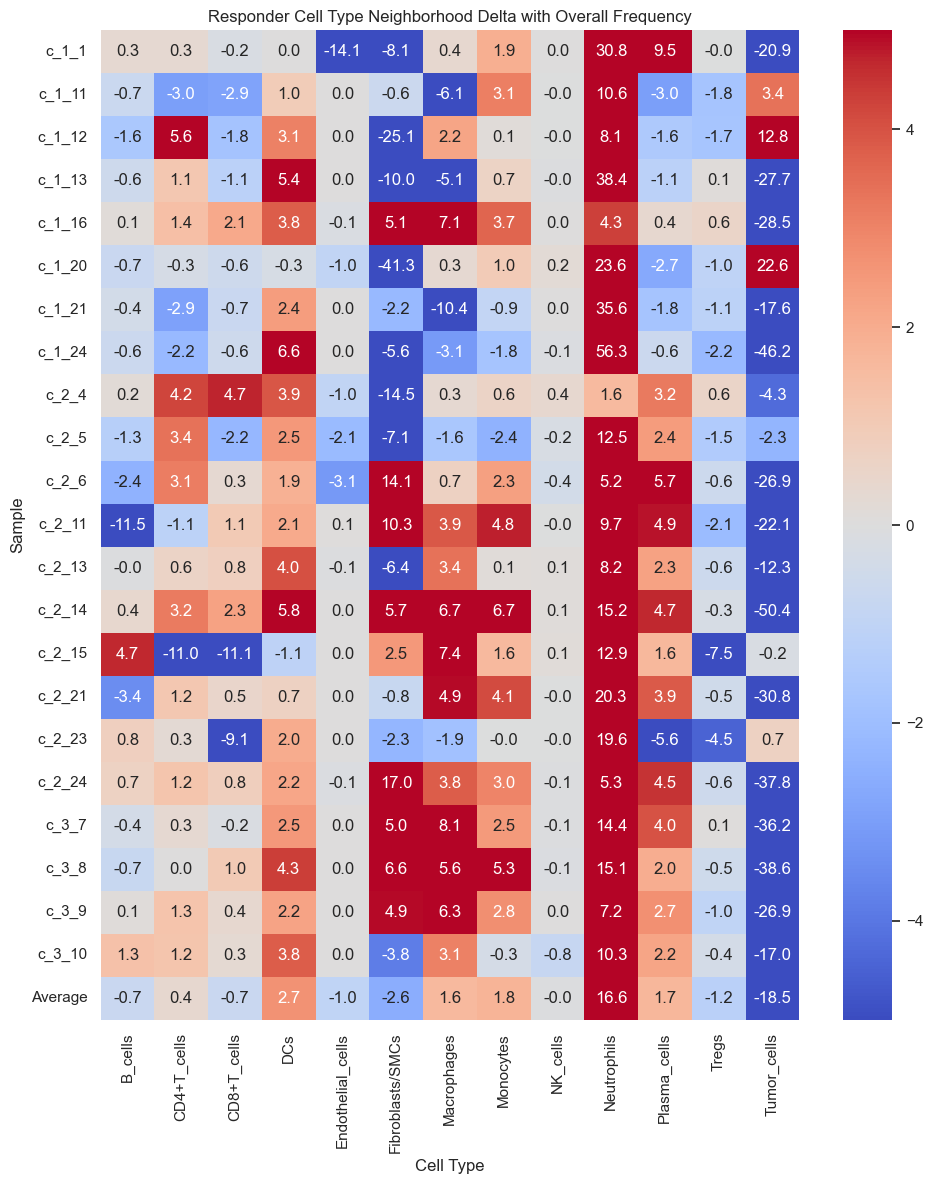

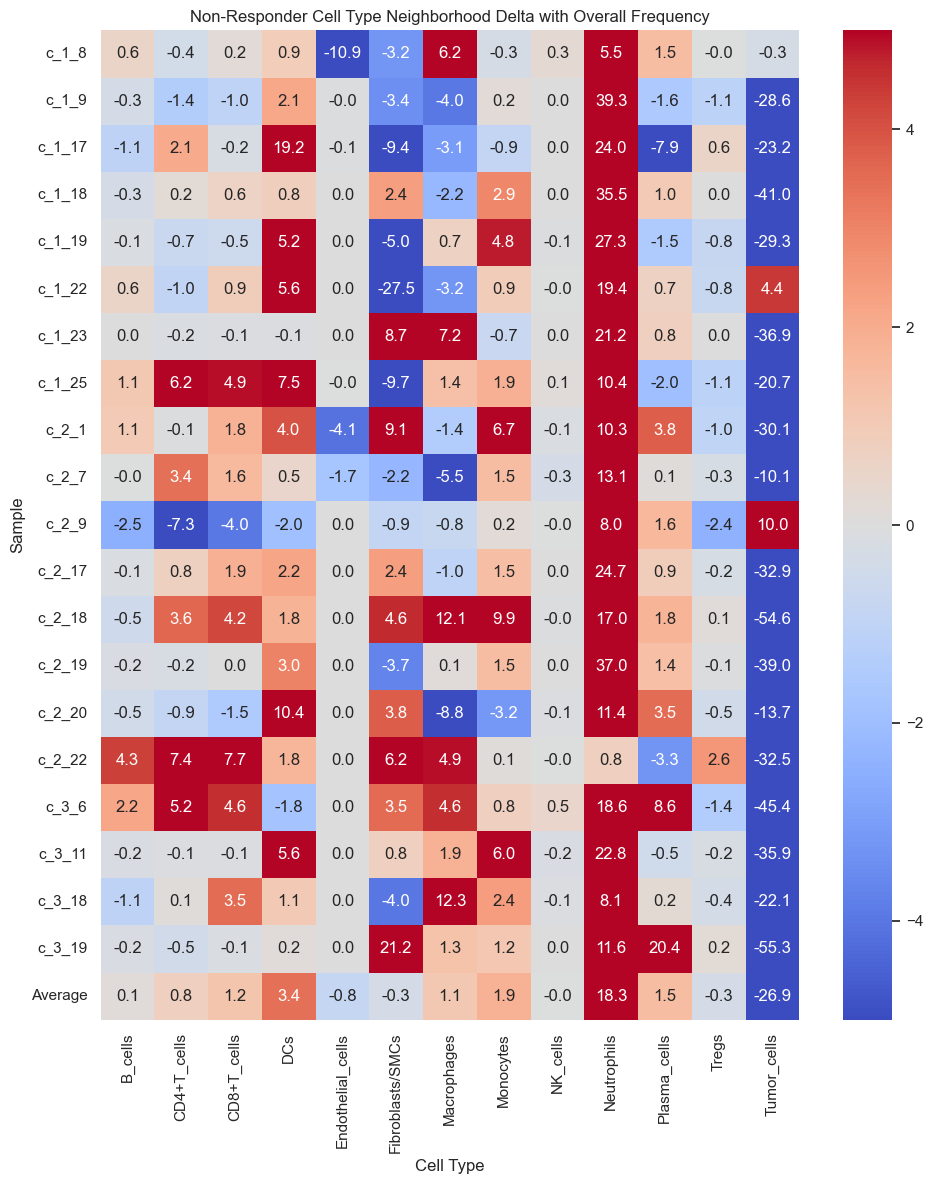

In [122]:
import importlib
import my_functions
import pandas as pd

importlib.reload(my_functions)

all_total_counts_R_percent.index.name = 'Sample ID'
output_percent_R.index.name = 'Sample ID'
all_total_counts_NR_percent.index.name = 'Sample ID'
output_percent_NR.index.name = 'Sample ID'

output_percent_R.index = output_percent_R.index.str.rstrip('_')
output_percent_NR.index = output_percent_NR.index.str.rstrip('_')

# Create a diff matrix
diff_responder=all_total_counts_R_percent-output_percent_R
diff_non_responder=all_total_counts_NR_percent-output_percent_NR

# Calculate the average across rows (column-wise mean)
average_row_r = pd.DataFrame([diff_responder.mean()], index=["Average"])
average_row_nr = pd.DataFrame([diff_non_responder.mean()], index=["Average"])

# Append it to the original DataFrame
diff_responder_with_avg = pd.concat([diff_responder, average_row_r])
diff_non_responder_with_avg = pd.concat([diff_non_responder, average_row_nr])

# Display the result
display(diff_responder_with_avg)
display(diff_non_responder_with_avg)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))
sns.heatmap(diff_responder_with_avg, cmap="coolwarm", center=0, annot=True, vmin=-5, vmax=5, fmt=".1f")
plt.title("Responder Cell Type Neighborhood Delta with Overall Frequency")
plt.xlabel("Cell Type")
plt.ylabel("Sample")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 12))
sns.heatmap(diff_non_responder_with_avg, cmap="coolwarm", center=0, annot=True, vmin=-5, vmax=5, fmt=".1f")
plt.title("Non-Responder Cell Type Neighborhood Delta with Overall Frequency")
plt.xlabel("Cell Type")
plt.ylabel("Sample")
plt.tight_layout()
plt.show()

## Delta K Means Clustering 

Do responders and non responders have different delta neighboorhood vs random chance. 

#### Elbow Plot for K Means Clutering

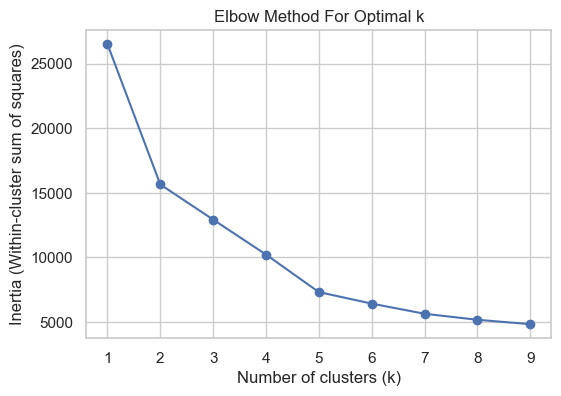

In [81]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.environ["OMP_NUM_THREADS"] = "1"
import warnings
warnings.filterwarnings("ignore")

# Combine Responder and non-responder matrix
full_matrix=pd.concat([diff_responder, diff_non_responder])

# # Step 1: Choose number of clusters (e.g., 3)
# k = 5  # You can change this or use elbow method (shown below)

# Now run KMeans
kmeans = KMeans(n_clusters=k, n_init=20, max_iter=300, random_state=42)
full_matrix['Cluster'] = kmeans.fit_predict(full_matrix)

inertia = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(full_matrix)
    inertia.append(km.inertia_)

# Plot the elbow curve
plt.figure(figsize=(6, 4))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.grid(True)
plt.show()

#### K means clustering

Cluster
1    18
0    14
2    10
Name: count, dtype: int64


[NbConvertApp] Converting notebook my_functions.ipynb to python
[NbConvertApp] Writing 24127 bytes to my_functions.py


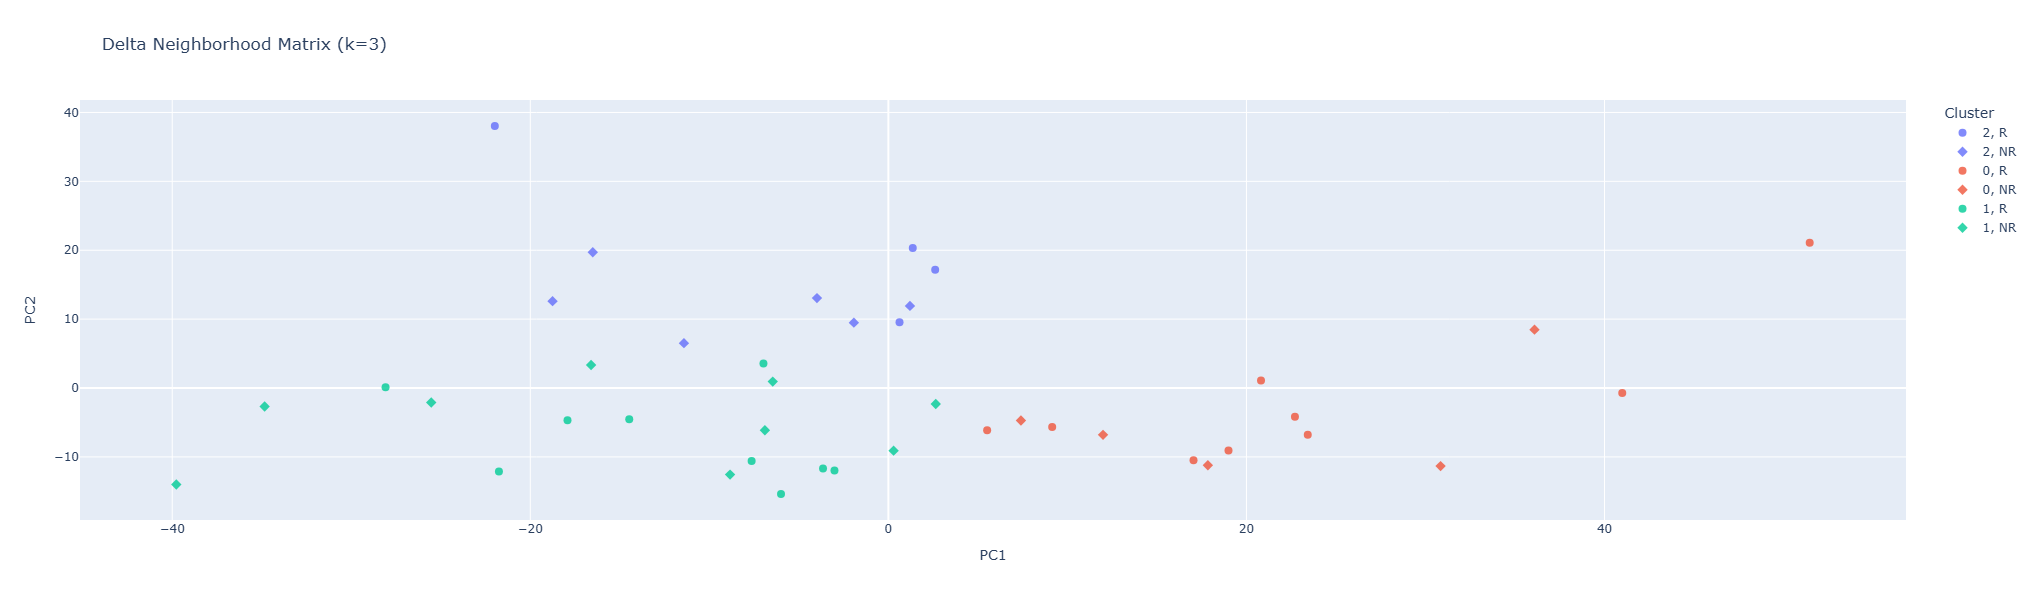

,Cluster,Non_Responder,Responder,Percent_Responder,Avg Tumor Cell Delta,Avg CD4+T_cells,Avg CD8+T_cells,Avg Tregs
0,0,5,9,64.285714,0.910918,-0.747161,-1.519401,-1.257483
1,1,9,9,50.000000,-31.694440,1.584225,1.655793,-0.084961
2,2,6,4,40.000000,-27.371318,-0.186056,-0.163249,-0.472985


In [114]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.environ["OMP_NUM_THREADS"] = "1"
import warnings
warnings.filterwarnings("ignore")
import plotly.express as px
import my_functions
import importlib
importlib.reload(my_functions)

def apply_get_sample_info(row: pd.Series) -> pd.Series:
    """
    Extracts 'Response' and 'Patient ID' for a given row using an external function.
    Parameters:
    -----------
    row : pd.Series
        A row from a pandas DataFrame, where the index contains 'Sample ID' as the row's name.
    Returns:
        - 'Response': Information retrieved from my_functions.get_sample_info
        - 'Patient ID': Information retrieved from my_functions.get_sample_info
    """
    sample_id = row.name  # 'Sample ID' is assumed to be the row's index
    result = my_functions.get_sample_info(adata, f"{sample_id}_")
    
    return pd.Series({
        'Response': result['Response'],
        'Patient ID': result['Patient ID']
    })

# Combine Responder and non-responder matrix
full_matrix=pd.concat([diff_responder, diff_non_responder])

# Step 1: Choose number of clusters (e.g., 3)
k = 3# You can change this or use elbow method (shown below)

# Step 2: Fit KMeans
kmeans = KMeans(n_clusters=k, n_init=20, max_iter=300, random_state=420)
full_matrix['Cluster'] = kmeans.fit_predict(full_matrix)

# Step 3: Inspect cluster assignments
print(full_matrix['Cluster'].value_counts())

# Step 4: Visualize clusters (e.g., using PCA for 2D view)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(full_matrix.drop('Cluster', axis=1))
full_matrix['PC1'] = components[:, 0]
full_matrix['PC2'] = components[:, 1]

# Add the new columns by applying the function row-wise
full_matrix_with_info=full_matrix
full_matrix_with_info[['Response', 'Patient ID']] = full_matrix_with_info.apply(apply_get_sample_info, axis=1)
# display(full_matrix_with_info)

# Step 3: Interactive plot
# Interactive plot with color by cluster and shape by response status
fig = px.scatter(
    full_matrix_with_info,
    x='PC1',
    y='PC2',
    color=full_matrix_with_info['Cluster'].astype(str),
    symbol='Response',  # Change marker shape based on Response
    title=f'Delta Neighborhood Matrix (k={k})',
    labels={'color': 'Cluster', 'symbol': 'Response'},
    hover_data=full_matrix_with_info.columns
)
fig.update_traces(marker=dict(size=8, opacity=0.8))
fig.update_layout(legend_title='Cluster')
fig.update_layout(width=900, height=600)
fig.show()

cluster_analysis=my_functions.cluster_response(full_matrix_with_info,"Run", "Cluster", "Response")['cluster_output_with_tumor_info']     
display(cluster_analysis)

## Box Plots Various Types

In order to better visualize the differences between responder and non-responder groups cell clustering we are going to examine the relationship between PMN neighboorhood and response. Particular iterest is going to be place on DCs, CD4, CD8, and tumor cells. 

### Box Plot - Neighbors Percentage

This type of box plot only relys on the neighborhood of PMN cells in each sample. Each point is the number of that type of cells within X distance (usually 15 microns) as a percentage of the total. Percentage of total neighbooring cells was used because raw counts have alot of counfounding factors. Even percentage analysis fails to take into account the overall cellular composition. 

**Steps to run**
1. Must run the cell under "Neighbooring Cell Matrix Creation - Output Matrix with % Neighboors for Entire Dataset" first to get the matrix

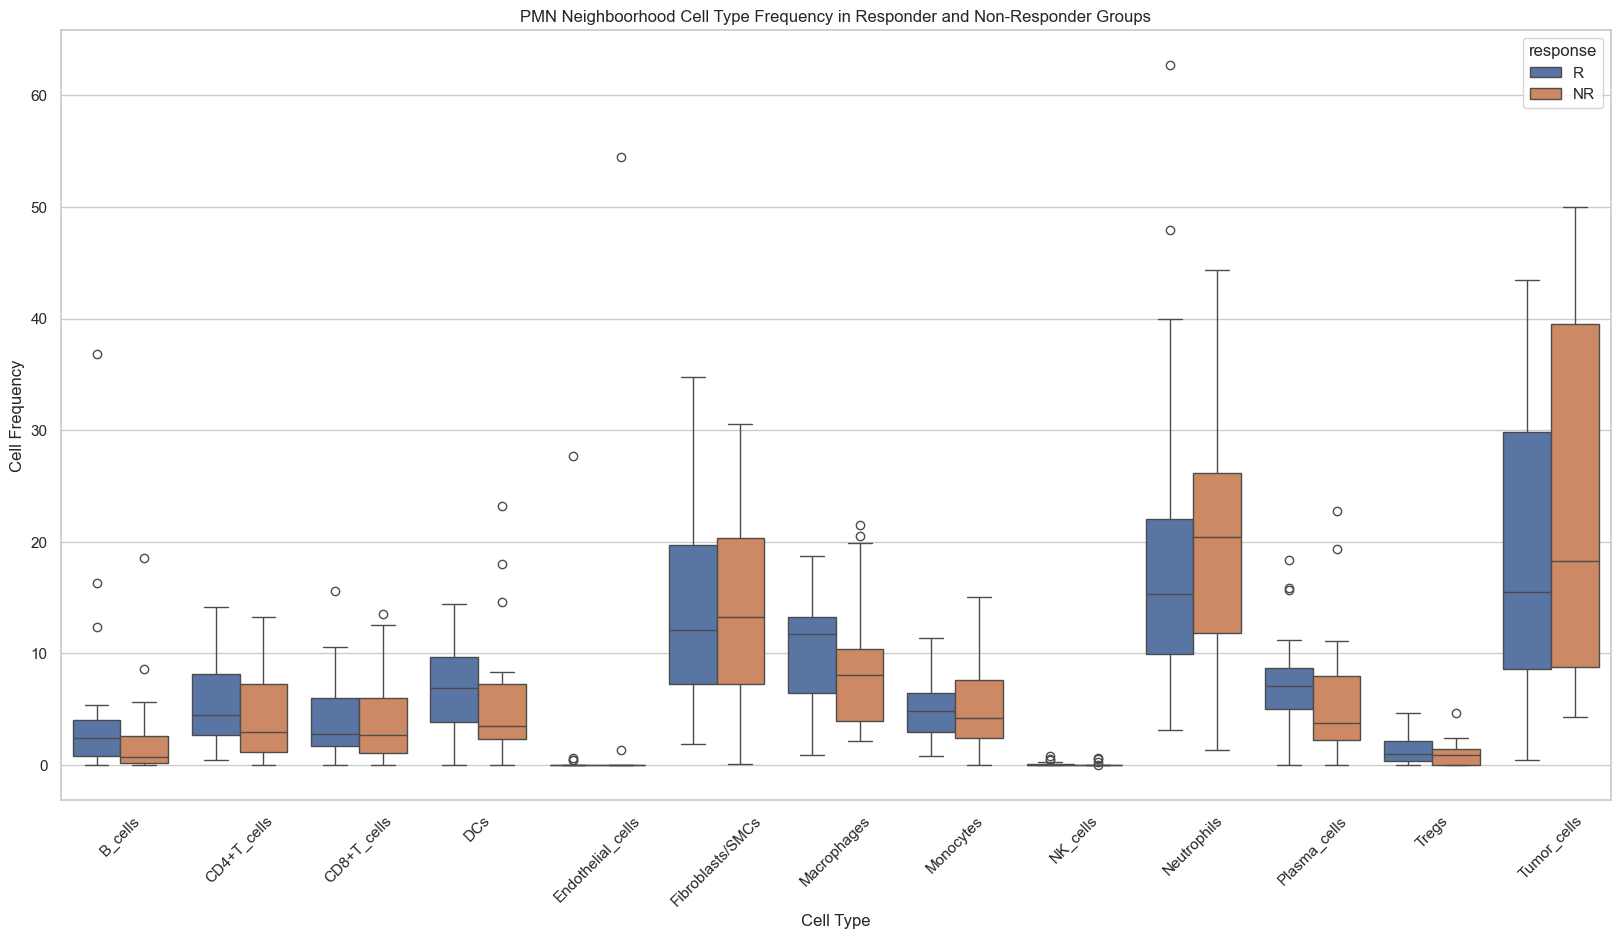

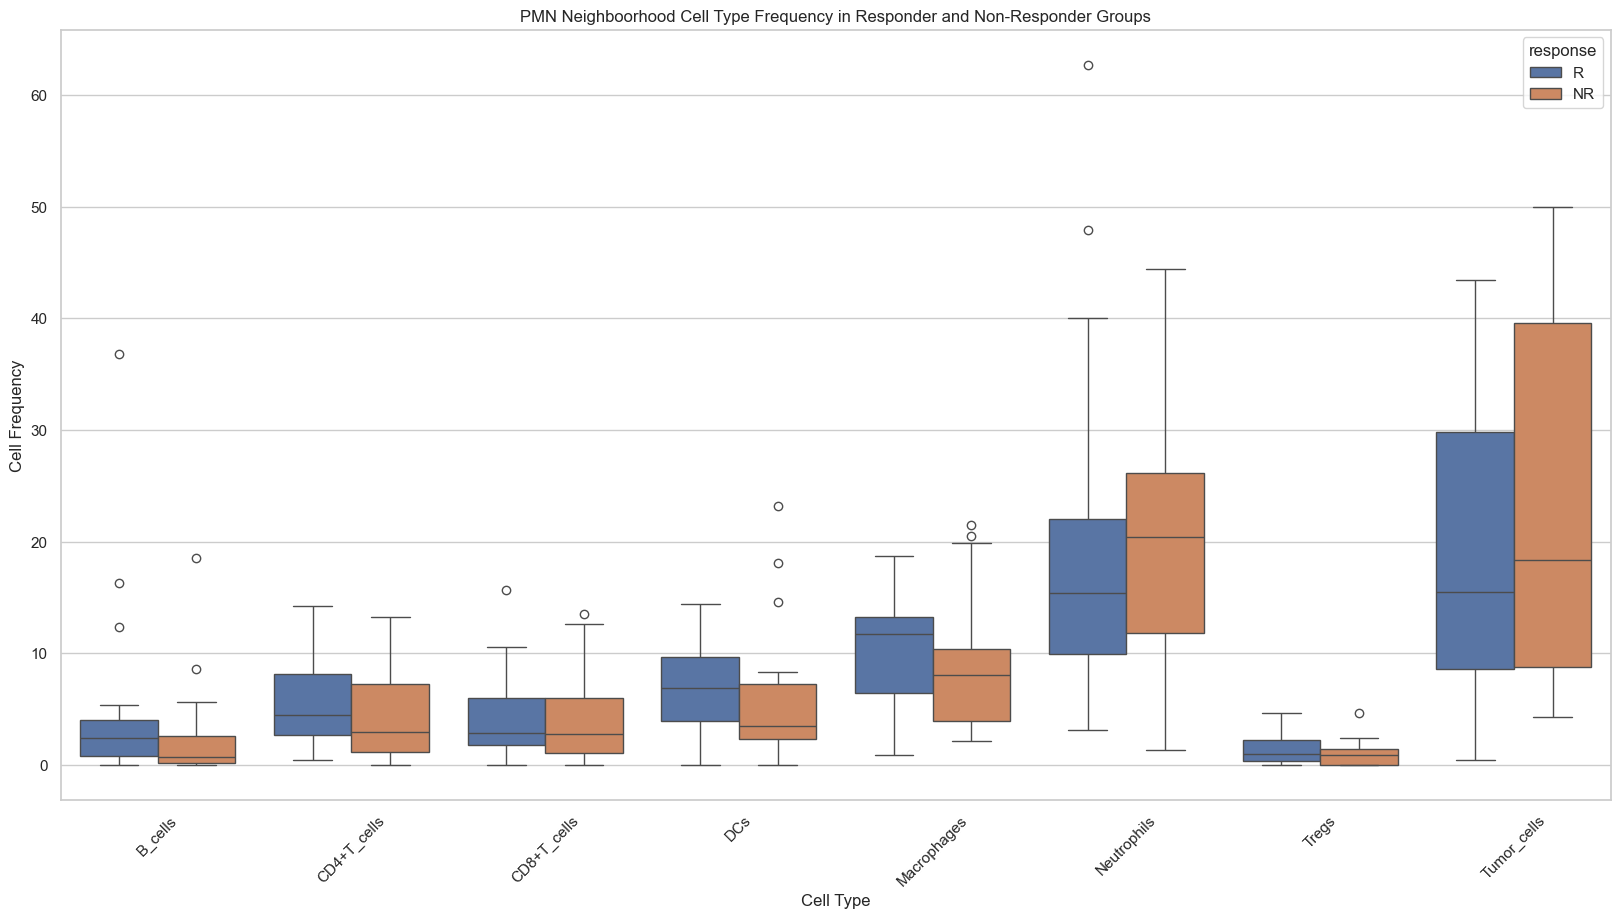

In [142]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Combine responder and non-responder groups
neighborhood_percent_R=all_total_counts_R_percent.copy()
neighborhood_percent_NR=all_total_counts_NR_percent.copy()
neighborhood_percent_R['response'] = 'R'
neighborhood_percent_NR['response'] = 'NR'
full_neighboor_matrix = pd.concat([neighborhood_percent_R, neighborhood_percent_NR])

# Melt the DataFrame to long format for seaborn
long_df = pd.melt(full_neighboor_matrix,
                  id_vars=["response"],
                  var_name="cell_type",
                  value_name="frequency")

plt.figure(figsize=(20,10))
sns.boxplot(data=long_df, x="cell_type", y="frequency", hue="response")
plt.xticks(rotation=45)
plt.ylabel("Cell Frequency")
plt.xlabel("Cell Type")
plt.title("PMN Neighboorhood Cell Type Frequency in Responder and Non-Responder Groups")
plt.show()

# Select Cell Plot
cell_types_to_keep = ["DCs", "B_cells", "CD4+T_cells", "CD8+T_cells", "Tregs", "Macrophages", "Neutrophils", "Tumor_cells"]
filtered_df = long_df[long_df['cell_type'].isin(cell_types_to_keep)]
plt.figure(figsize=(20,10))
sns.boxplot(data=filtered_df, x="cell_type", y="frequency", hue="response")
plt.xticks(rotation=45)
plt.ylabel("Cell Frequency")
plt.xlabel("Cell Type")
plt.title("PMN Neighboorhood Cell Type Frequency in Responder and Non-Responder Groups")
plt.show()

### Box Plot - Delta Neighbors Percentage 

This box plot adds a correcting factor for the plot above. It compares the pmn neighbhorhood between responders and non-responders. 

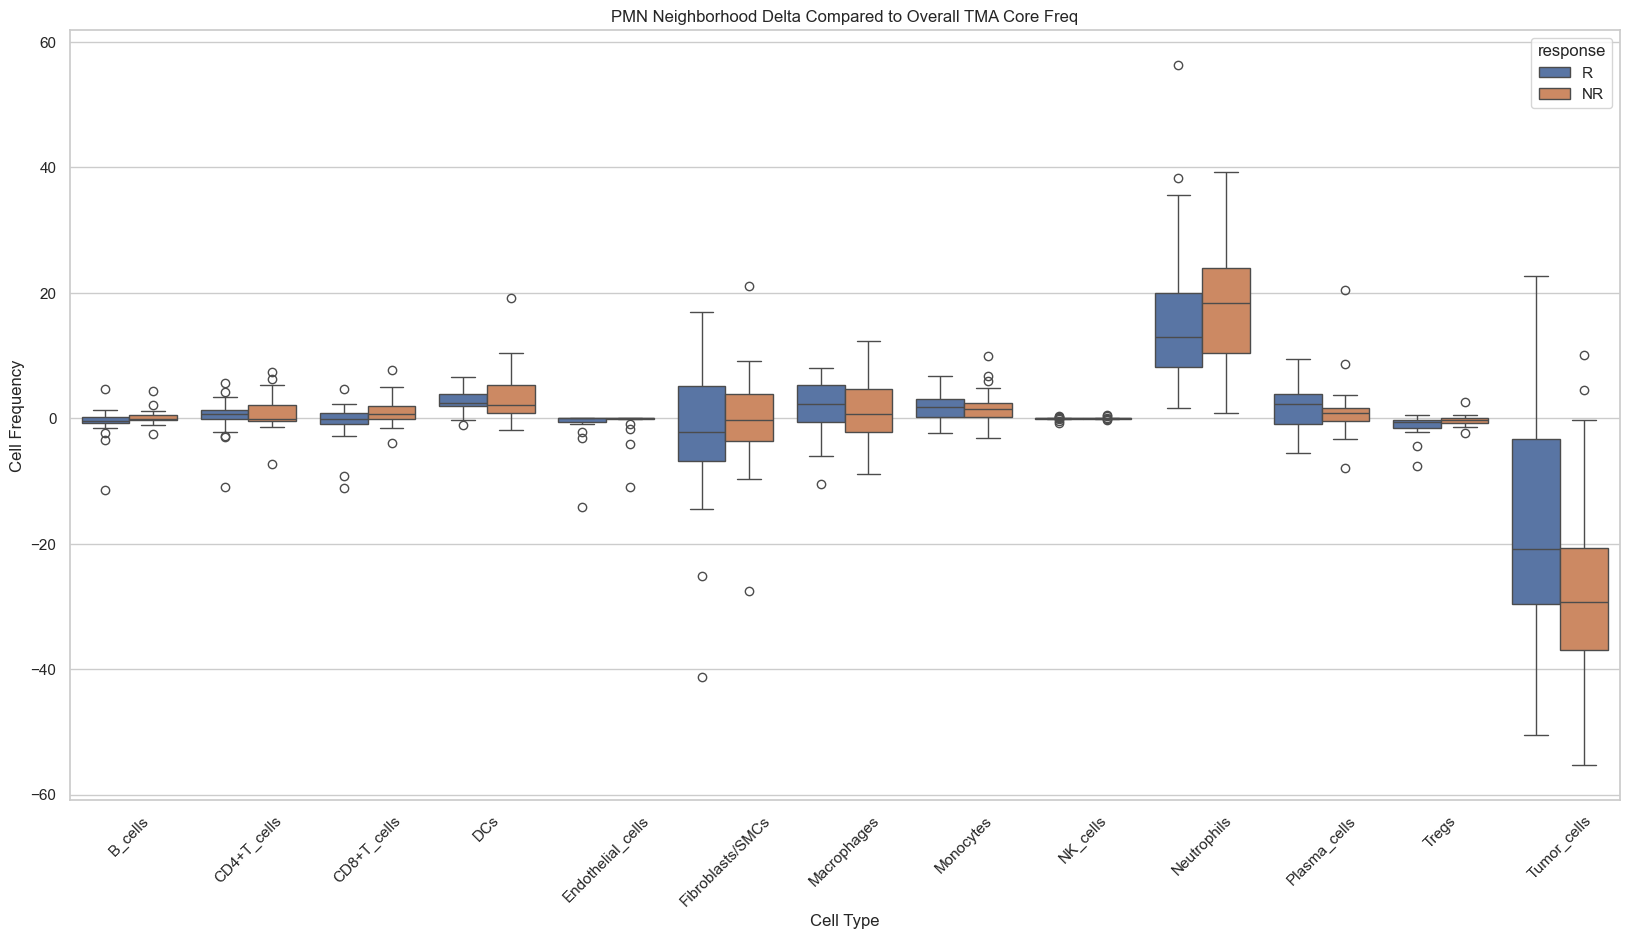

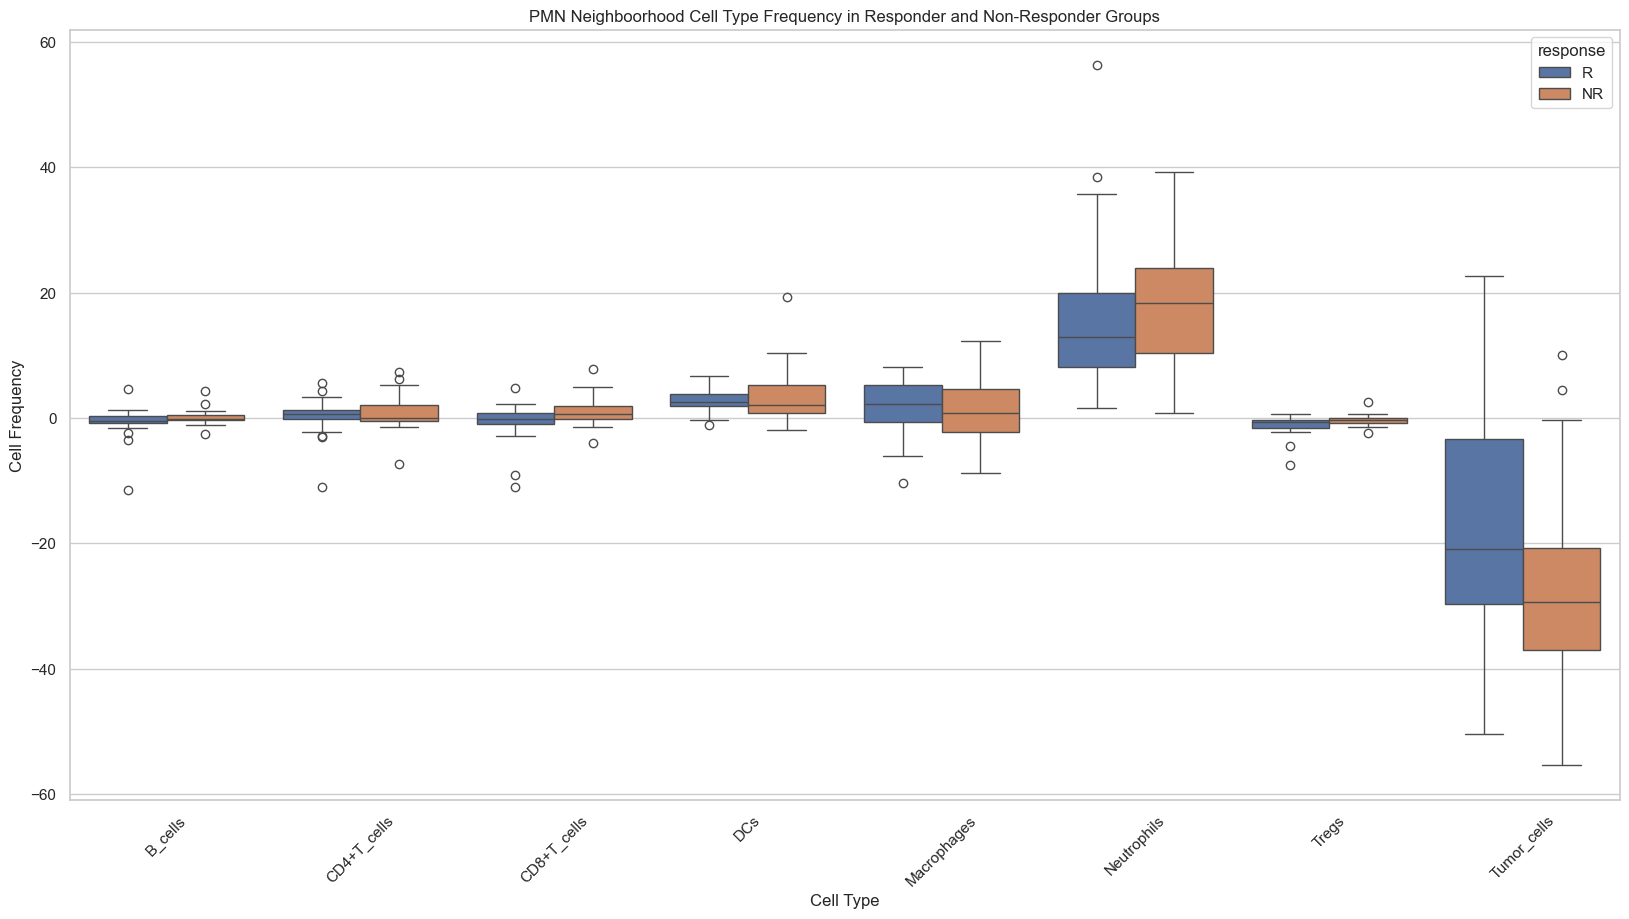

In [143]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Combine responder and non-responder groups
delta_neighborhood_percent_R=diff_responder_with_avg.copy()
delta_neighborhood_percent_NR=diff_non_responder_with_avg.copy()
delta_neighborhood_percent_R['response'] = 'R'
delta_neighborhood_percent_NR['response'] = 'NR'
delta_full_neighboor_matrix = pd.concat([delta_neighborhood_percent_R, delta_neighborhood_percent_NR])

# Melt the DataFrame to long format for seaborn
long_df = pd.melt(delta_full_neighboor_matrix,
                  id_vars=["response"],
                  var_name="cell_type",
                  value_name="frequency")

plt.figure(figsize=(20,10))
sns.boxplot(data=long_df, x="cell_type", y="frequency", hue="response")
plt.xticks(rotation=45)
plt.ylabel("Cell Frequency")
plt.xlabel("Cell Type")
plt.title("PMN Neighborhood Delta Compared to Overall TMA Core Freq")
plt.show()

# Select Cell Plot
cell_types_to_keep = ["DCs", "B_cells", "CD4+T_cells", "CD8+T_cells", "Tregs", "Macrophages", "Neutrophils", "Tumor_cells"]
filtered_df = long_df[long_df['cell_type'].isin(cell_types_to_keep)]
plt.figure(figsize=(20,10))
sns.boxplot(data=filtered_df, x="cell_type", y="frequency", hue="response")
plt.xticks(rotation=45)
plt.ylabel("Cell Frequency")
plt.xlabel("Cell Type")
plt.title("PMN Neighboorhood Cell Type Frequency in Responder and Non-Responder Groups")
plt.show()